In [1]:
import numpy as np
from numpy import random as nprnd
import pandas as pd
import string as str
from math import *

#scipy stat
from scipy.stats import kurtosis
from scipy.stats import skewnorm,skew
from scipy.stats import boxcox
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
import math
import matplotlib.pyplot as plt
import seaborn as sns
# Pkg import Date Time
from pandas.tseries.frequencies import to_offset
###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from patsy import dmatrices,dmatrix

###################################################
'''sklearn'''
###################################################
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.utils import resample
import os


In [2]:
#extra code
def tableDispFormatt(yourString):
    fixLen = 90
    startLine = '==============================='
    textLen = len(yourString)
    endLineLen = fixLen - (len(startLine)+textLen)
    endLine = ''
    for i in np.arange(0,endLineLen,1):
        endLine += '='
    print(startLine,yourString,endLine)

#### Prepare data for Statically regressions analysis 

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        print(path)

# Replace with the actual path printed above
path = '/kaggle/input/datasets/yasserh/housing-prices-dataset/Housing.csv'
df = pd.read_csv(path)

# Preview the data
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [4]:
# Numerical variables
numerical_vars = [    
    "area",        # Square feet
    "bedrooms",    # Number of bedrooms
    "bathrooms",   # Number of bathrooms
    "stories",     # Number of floors
    "parking"      # Number of parking spaces
]
# Categorical variables (binary: Yes/No)
categorical_binary_vars = [
    "mainroad",        # Near main road (Yes/No)
    "guestroom",       # Guest room available (Yes/No)
    "basement",        # Basement present (Yes/No)
    "hotwaterheating", # Hot water heating available (Yes/No)
    "airconditioning", # Air conditioning available (Yes/No)
    "prefarea"         # Preferred area (Yes/No)
]
# Categorical variables (multiclass)
categorical_multiclass_vars = [
    "furnishingstatus" # Furnished / Semi-furnished / Unfurnished
]

# Apply StandardScaler
scaler = StandardScaler()
df[numerical_vars] = scaler.fit_transform(df[numerical_vars])
print('Scaled dataframed colums: ',df.columns)

# Original column names
list1 = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
         'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
         'parking', 'prefarea', 'furnishingstatus']

# Shortened names
list2 = ['PR', 'AR', 'BD', 'BT', 'ST', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PARK', 'PAREA', 'FSS']
df.columns = list2
# Create mapping dictionary
col_mapping = dict(zip(list1, list2))

# Numerical variables (mapped)
numerical_vars = [col_mapping[var] for var in ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']]

# Categorical binary variables (mapped)
categorical_binary_vars = [col_mapping[var] for var in ['mainroad', 'guestroom', 'basement', 
                                                       'hotwaterheating', 'airconditioning', 'prefarea']]

# Categorical multiclass variables (mapped)
categorical_multiclass_vars = [col_mapping[var] for var in ['furnishingstatus']]

print("Column Mapping:\n", col_mapping)
print("\nNumerical Variables:", numerical_vars)
print("Categorical Binary Variables:", categorical_binary_vars)
print("Categorical Multiclass Variables:", categorical_multiclass_vars)
for var in categorical_binary_vars:
    #print(f"\nFrequency count for {var}:")
    #print(df[var].value_counts())
    pass

# Map binary categorical variables (Yes=1, No=0)
df[categorical_binary_vars] = df[categorical_binary_vars].map(lambda x: 1 if f'{x}'.lower() == 'yes' else 0)

# Apply One-Hot Encoding only on multiclass categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_multiclass_vars, prefix=categorical_multiclass_vars, drop_first=False)
# For 3 category we required only 2 dummy variable. So we can dropped one.
df_encoded.drop(['FSS_furnished'],axis='columns',inplace=True)

# Ensure PR has strictly positive values (Box-Cox requirement)
if (df_encoded['PR'] <= 0).any():
    raise ValueError("Box-Cox transformation requires strictly positive values in PR.")

# Apply Box-Cox transformation
df_encoded['PR_BC'], fitted_lambda = boxcox(df_encoded['PR'])
df_encoded.columns = ['PR', 'AR', 'BD', 'BT', 'ST', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PARK',
       'PAREA', 'FSS_SEMI_FUR', 'FSS_UN_FUR', 'PR_BC']
# Display result
print("Encoded DataFrame colums name:")
print(df_encoded.columns)

list1 = ['AR', 'BD', 'BT', 'ST', 'PARK']
list2 = ['MRD', 'GR', 'BS', 'HW', 'AC', 'PAREA','FSS_SEMI_FUR', 'FSS_UN_FUR']

# Multiply (concatenate) each element in list1 with each element in list2
list3 = [f"{a}*{b}" for a in list1 for b in list2]

# Display result
print("Resulting list3:")
# Append all lists into final list
final_list = list1 + list2 + list3

# Display result
#print("Final List:")
#print(final_list)

single_line_sol = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS_SEMI_FUR + FSS_UN_FUR + AR*MRD + AR*GR + AR*BS + AR*HW + AR*AC + AR*PAREA + AR*FSS_SEMI_FUR + AR*FSS_UN_FUR + BD*MRD + BD*GR + BD*BS + BD*HW + BD*AC + BD*PAREA + BD*FSS_SEMI_FUR + BD*FSS_UN_FUR + BT*MRD + BT*GR + BT*BS + BT*HW + BT*AC + BT*PAREA + BT*FSS_SEMI_FUR + BT*FSS_UN_FUR + ST*MRD + ST*GR + ST*BS + ST*HW + ST*AC + ST*PAREA + ST*FSS_SEMI_FUR + ST*FSS_UN_FUR + PARK*MRD + PARK*GR + PARK*BS + PARK*HW + PARK*AC + PARK*PAREA + PARK*FSS_SEMI_FUR + PARK*FSS_UN_FUR'
single_line_sol_bc = 'PR_BC ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS_SEMI_FUR + FSS_UN_FUR + AR*MRD + AR*GR + AR*BS + AR*HW + AR*AC + AR*PAREA + AR*FSS_SEMI_FUR + AR*FSS_UN_FUR + BD*MRD + BD*GR + BD*BS + BD*HW + BD*AC + BD*PAREA + BD*FSS_SEMI_FUR + BD*FSS_UN_FUR + BT*MRD + BT*GR + BT*BS + BT*HW + BT*AC + BT*PAREA + BT*FSS_SEMI_FUR + BT*FSS_UN_FUR + ST*MRD + ST*GR + ST*BS + ST*HW + ST*AC + ST*PAREA + ST*FSS_SEMI_FUR + ST*FSS_UN_FUR + PARK*MRD + PARK*GR + PARK*BS + PARK*HW + PARK*AC + PARK*PAREA + PARK*FSS_SEMI_FUR + PARK*FSS_UN_FUR'
two_line_sol   = 'PR ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS_SEMI_FUR + FSS_UN_FUR'
two_line_sol_bc   = 'PR_BC ~ AR + BD + BT + ST + PARK + MRD + GR + BS + HW + AC + PAREA + FSS_SEMI_FUR + FSS_UN_FUR'

Scaled dataframed colums:  Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
Column Mapping:
 {'price': 'PR', 'area': 'AR', 'bedrooms': 'BD', 'bathrooms': 'BT', 'stories': 'ST', 'mainroad': 'MRD', 'guestroom': 'GR', 'basement': 'BS', 'hotwaterheating': 'HW', 'airconditioning': 'AC', 'parking': 'PARK', 'prefarea': 'PAREA', 'furnishingstatus': 'FSS'}

Numerical Variables: ['PR', 'AR', 'BD', 'BT', 'ST', 'PARK']
Categorical Binary Variables: ['MRD', 'GR', 'BS', 'HW', 'AC', 'PAREA']
Categorical Multiclass Variables: ['FSS']
Encoded DataFrame colums name:
Index(['PR', 'AR', 'BD', 'BT', 'ST', 'MRD', 'GR', 'BS', 'HW', 'AC', 'PARK',
       'PAREA', 'FSS_SEMI_FUR', 'FSS_UN_FUR', 'PR_BC'],
      dtype='object')
Resulting list3:


#### Hist plot to see visual effect of Box-Cox transformed on price data


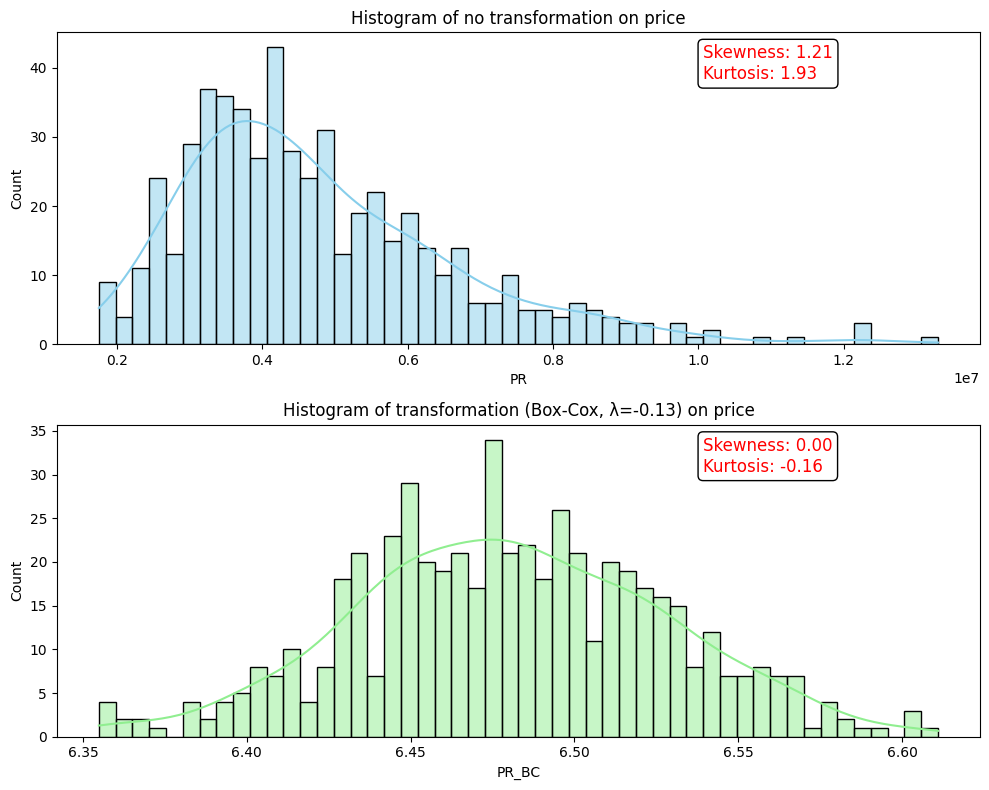

In [5]:
# Example: assume y_no_transform is your target variable (Series)
y_no_transform = df_encoded['PR']   # replace with your actual target column

# Apply Box-Cox transformation (requires strictly positive values)
y_boxcox = df_encoded['PR_BC']

# Compute skewness and kurtosis
skew_raw, kurt_raw = skew(y_no_transform), kurtosis(y_no_transform)
skew_box, kurt_box = skew(y_boxcox), kurtosis(y_boxcox)

# Create subplots (2 rows, 1 column)
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# First row: raw y_no_transform
sns.histplot(y_no_transform, kde=True, ax=axes[0],bins=50, color="skyblue")
axes[0].set_title("Histogram of no transformation on price")
axes[0].annotate(f"Skewness: {skew_raw:.2f}\nKurtosis: {kurt_raw:.2f}",
                 xy=(0.70, 0.85), xycoords="axes fraction",
                 fontsize=12, color="red",  # <-- text color red
                 bbox=dict(boxstyle="round", fc="white", ec="black"))

# Second row: Box-Cox transformed y
sns.histplot(y_boxcox, kde=True, ax=axes[1],bins=50, color="lightgreen")
axes[1].set_title(f"Histogram of transformation (Box-Cox, λ={fitted_lambda:.2f}) on price")
axes[1].annotate(f"Skewness: {skew_box:.2f}\nKurtosis: {kurt_box:.2f}",
                 xy=(0.70, 0.85), xycoords="axes fraction",
                 fontsize=12, color="red",  # <-- text color red
                 bbox=dict(boxstyle="round", fc="white", ec="black"))

plt.tight_layout()
plt.show()

**Histogram (Box-Cox Transformation)**: After applying Box-Cox (λ ≈ -0.13), the distribution becomes much more symmetric. Skewness ≈ 0.00 and kurtosis ≈ -0.16 show that the transformed variable is very close to normal. This stabilizes variance, improves coefficient estimation, and makes diagnostic statistics (like Mallows’ C_k or ridge trace plots) more reliable.

- Without transformation: Models may overfit, coefficients can explode, and prediction intervals are misleading.
- With Box-Cox: The target variable behaves more like a Gaussian, which aligns with regression assumptions and makes ridge regularization more effective



In [6]:
y_single_sol,X_single_sol = dmatrices(formula_like  = single_line_sol,
                                      data=df_encoded, 
                                      return_type='dataframe')

y_single_sol_bc,X_single_sol_bc = dmatrices(formula_like  = single_line_sol_bc,
                                      data=df_encoded, 
                                      return_type='dataframe')

y_two_sol,X_two_sol = dmatrices(formula_like  = two_line_sol,
                                      data=df_encoded, 
                                      return_type='dataframe')

y_two_sol_bc,X_two_sol_bc = dmatrices(formula_like  = two_line_sol_bc,
                                      data=df_encoded, 
                                      return_type='dataframe')

#### Ridge Regression: Bias–Variance Tradeoff:

#### Topic covered:

- What is the actual problem in OLS models when strong multicollinearity present in dataset.
- How the ride regressions come into picture and hoe=w we can understand this MSE


Problem with Least Squares OLS models:
Traditional least squares estimation (OLS) can produce unstable and inflated regression coefficients. Variance of coefficients is inflated, making estimates too large in magnitude and inconsistent across samples. This instability arises because least squares enforces unbiasedness, which can result in high variance and unreliable estimates.The Gauss–Markov theorem guarantees least squares has minimum variance among unbiased linear estimators, but this variance can still be very large. Result: wide confidence intervals and unstable point estimates.

**Ridge regression addresses** this by allowing bias in exchange for lower variance, leading to more stable and interpretable models. The key insight is that the mean squared error (MSE) of an estimator includes both variance and bias squared:

One way to alleviate this problem with Least Squares OLS modelsis to drop the requirement that the estimator of β be unbiased. Suppose that we can find a biased estimator of β, say $\hat {\beta }^{*}$, that has a **smaller variance** than the unbiased estimator $\hat {\beta }$ The mean square error of the estimator $\hat {\beta }^{*}$ is defined as

Mean Squared Error (MSE):

The quality of an estimator is measured by MSE:

$MSE(\hat {\beta }^{*})$ =  $Var({\beta }^{*})$ + $E((\hat{\beta}^*)) - (\beta)^2$     ---- (1)

$OR$

$\mathrm{MSE}(\hat {\beta }^*)=\mathrm{Var}(\hat {\beta }^*)+(\mathrm{bias\  in\  }\hat {\beta }^*)^2$ --(2)

Our Goel to achieve smaller variance.

MSE represents the expected squared distance between the estimator and the true parameter. Even if bias is introduced, if variance reduction is large enough, the overall MSE can be smaller than that of the unbiased estimator. This makes the biased estimator more reliable in practice.

Note that the **MSE** is just the **expected squared distance from** $\hat {\beta }^*$ to $\beta$. By allowing a small amount of bias in $\hat {\beta }^*$, the variance of $\hat {\beta }^*$ can be made small such that the **MSE** of $\hat {\beta }^*$ is less than the variance of the unbiased estimator $\hat {\beta }$. 

![alt text](image.png)
![alt text](image-1.png)

Figure b illustrates a situation where the variance of the biased estimator is considerably smaller than the variance of the unbiased estimator (Figure a). Consequently, confidence intervals on *\beta*  would be much narrower using the biased estimator. The small variance for the biased estimator also implies that $\hat {\beta }^*$ is a more stable estimator of $\beta$  than is the unbiased estimator $\hat {\beta }$.

A number of procedures have been developed for obtaining biased estimators of regression coefficients. One of these procedures is ridge regression.

***By accepting a small bias, Ridge regression can reduce variance enough to lower the overall MSE, making the estimator more reliable.***


#### Understanding Ridge regressions

#### Understanding Ridge regressions procedure and how it's different from Least square equations:

Let regression model in matrix form:

$y=X\beta +\epsilon$ 

where
- y = vector of observed responses
- X = design matrix (predictors)
- $\beta$  = vector of regression coefficients
- $\epsilon$  = error term


least-squares normal equations

$X'X\hat {\beta }=X'y$           ----- ($i$)

least-squares estimator of $\beta $

$\hat {\beta }=(X'X)^{-1}X'y$    ---- ($ii$)

The least-squares method minimizes the sum of squared residuals:

$S(\beta )=(y-X\beta )'(y-X\beta )$    ------ ($iii$)

Derivations of equations i, ii, iii are out of scope for this Notebook.

A number of procedures have been developed for obtaining biased estimators of regression coefficients to mminized variance. One of these procedures is ridge regression.

#### Find ridge estimator $\hat {\beta }_R$ from Lest square $eq^n$ :

$(X'X+kI)\hat {\beta }_R=X'y\quad$ ------($iv$)

$\hat {\beta }_R=(X'X+kI)^{-1}X'y\quad$  ----------($v$)

you can see clearly $eq^n$ iv & v are obtained form add const term $kI$ in $eq^n$ i & ii.

where $k\geq 0$ is a constant selected by the analyst. Note that when k=0 in $eq^n$ (iv) & (v), the ridge estimator is the least-squares estimator.

Equations (iv) & (v) obtained from least square equations by adding const term. So we can say that equations (iv & v) are the linear transformations of Lest-square estimations.

#### Ridge estimator is a linear transformation of the least-squares estimator:

$\hat {\beta }_R=(X'X+kI)^{-1}X'y$

$\hat {\beta }_R=(X'X+kI)^{-1}(X'X)\hat {\beta }$

$\hat {\beta }_R=Z_k\hat {\beta }$     ----- ($vi$)

Therefore, since $E(\hat {\beta }_R)=E(Z_k\hat {\beta })=Z_k\beta$ , $\hat {\beta }_R$ is a biased estimator of $\beta$. 


So the equations (vi) clearly explained Ridge regressions are the linear transform of Least square estimator.

#### Calculate varince of ridge regressions:

Variance of Least square estimator:

$\mathrm{Var}(\hat {\beta })=\sigma ^2(X'X)^{-1}$ 

Where
In ordinary least squares (OLS), the error variance is estimated as:

$\hat {\sigma }^2=\frac{1}{n-p}\sum _{i=1}^n\hat {\epsilon }_i^2=MS_{res}=\frac{SS_{res}}{n-1}$

$\hat {\sigma }^2=\frac{1}{n-p}\sum _{i=1}^n\hat {\epsilon }_i^2 = \frac{1}{n-p}\sum _{i=1}^n(y - \hat y)^2$

The covariance matrix of $\hat {\beta }_R$ (ridge regression estimator) is

$\mathrm{Var}(\hat {\beta }_R)=\sigma ^2(X'X+kI)^{-1}X'X(X'X+kI)^{-1}$ -----($vi$)

It shows how the variance depends on the regularization parameter $k$. Adding $kI$ stabilizes the inversion of $X'X$, reducing variance compared to ordinary least squares (OLS). This **reduction in variance** comes at the cost of introducing bias, which is the essence of the bias–variance tradeoff in ridge regression.
Or simply say s the regularization parameter $k$ increases, the variance term decreases.

#### Mean Square error of Ridge estimator:

$\mathrm{MSE}(\hat {\beta }_R)=\mathrm{Var}(\hat {\beta }_R)+(\mathrm{bias\  in\  }\hat {\beta }_R)^2$

$\mathrm{MSE}(\hat {\beta }_R)$ = $\sigma ^2\, \mathrm{Tr}\left[ (X'X+kI)^{-1}X'X(X'X+kI)^{-1}\right]$ + $(+k^{2}\beta ^{\prime }(\mathbf{X}^{\prime }\mathbf{X}+k\mathbf{I})^{-2}\beta)$

$\mathrm{MSE}(\hat {\beta }_R)$=$\sigma ^{2}\sum _{j=1}^{p}\frac{\lambda _{j}}{(\lambda _{j}+k)^{2}}+\frac{k^{2}\beta ^{\prime }\beta}{(\mathbf{X}^{\prime }\mathbf{X}+k\mathbf{I})^{2}}$  --- ($vii$)

where $\lambda _{1},\lambda _{2},...,\lambda _{p}$ are the eigenvalues of $\mathbf{X}^{\prime }\mathbf{X}$.

The first term on the right-hand side of (vii) is the sum of variances of the parameters in $\hat {\beta }_R$ and the second term is the square of the bias. If $k>0$, note that the bias in $\hat {\beta }_R$ increases with $k$. However, the variance decreases as $k$ increases. In using ridge regression we would.

#### Relations between  Mean Square error of Ridge estimator & $\hat \beta_R$:

The ridge trace, as $k$ is increased, some of the ridge estimates will vary dramatically. At some value of $k$, the ridge estimates $\hat {\beta }_R$ will *stabilize*. The objective is to select a reasonably small value of $k$ at which the ridge estimates $\hat {\beta }_R$ are stable. **This will produce a set of estimates with smaller MSE than the least-squares estimates.**


#### Explanations of eqn (viii):

We know that

$Multicollinearity \propto \frac{1}{\text{eigenvalue}(\lambda )}$

if $\lambda$ increased then Multicollinearity Reduced. Now from eqn(viii) first term

$\mathbf{MSE}(\^{\beta }_{R})\propto \frac{\lambda _{i}}{(\lambda _{i}+k)^{2}}$

if eigen value of $\lambda _{i}$ increase denomenator of above eqn do increase rapidly and MSE reduced. Also you notice notice if $k$ increase then MSE Also decrease.

Mean Squared Error (MSE): is a measure of the overall quality of an estimator or model prediction. It quantifies the average squared difference between the estimated values and the actual true values.

**A lower MSE indicates a better model.** 

As seen in the previous , 

$\mathbf{MSE}=\mathbf{Variance}+\mathbf{Bias}^{2}+\mathbf{IrreducibleError}$

**Variance**: How much the model predictions vary if we train the model on different data sets. High variance often means overfitting.

**Bias**: The difference between the expected (average) prediction of our model and the true value we are trying to predict. High bias often means underfitting.T

Ridge regression works by increasing the bias slightly in exchange for a significant reduction in variance, which usually leads to a lower overall MSE.

#### what happen $k$ = 0

All equations simply turn to OLS lest square models.

#### The OLS residual sum of square:

$SS_{\mathrm{Res}}=y'y-\hat {\beta }X'y$
- $y'y$: the inner product of the response vector with itself (essentially the sum of squared observed values).
- $\hat {\beta }X'y$: the fitted component, involving the estimated regression coefficients \hat {\beta } and the predictors X.

#### The OLS residual mean of square:

$MS_{\mathrm{Res}}=\frac{SS_{\mathrm{Res}}}{n-p}$
Where:
- $MS_{\mathrm{Res}}$: Residual mean square, an estimate of the variance of the error term.
- $SS_{\mathrm{Res}}$: Residual sum of squares, the total unexplained variation after fitting the model.
- $n$: Number of observations (sample size).
- $p$: Number of parameters estimated in the model (including the intercept).

### On the basis of OLS Residual sum of squares calculate ($SS{}_{Res}$) for the ridge estimator:

$SS_{Res}=(y-X\hat {\beta }_R)'(y-X\hat {\beta }_R)$

$SS_{Res}=(y-X\hat {\beta })'(y-X\hat {\beta })+(\hat {\beta }_R-\hat {\beta })'X'X(\hat {\beta }_R-\hat {\beta })$   -------   ($viii$)

Since the first term on the right-hand side ($viii$) is the residual sum of squares for the least-squares estimates $\hat {\beta }$, we see that as k increases, the residual sum of squares increases. 

Consequently, because the total sum of squares is fixed, $R^2$ decreases as $k$ increases.

👉 Therefore, the **ridge estimate will not necessarily provide the best 'fit' to the data**, but this should not overly concern us, since we are more interested in obtaining a stable set of parameter estimates. The ridge estimates may result in an equation that does a better job of predicting future observations than would least squares (although there is no conclusive proof that this will happen).

- Increasing k worsens the in-sample fit ($R^2$ decreases).
- But stability of parameter estimates improves.
- Ridge regression prioritizes predictive performance and stability over maximizing fit to the training data

#### Total Sum of Squares ($SS_T$): Same as OLS

$SS_T=\mathbf{y}'\mathbf{y}-\frac{\left( \sum _{i=1}^ny_i\right) ^2}{n}$
Where:
- $\mathbf{y}$ = vector of observed values $(y_1,y_2,\dots ,y_n)$
- $n$ = number of observations
- $\mathbf{y}'\mathbf{y}=\sum _{i=1}^ny_i^2$ (sum of squares of all observations)
- $\left( \sum _{i=1}^ny_i\right) ^2/n$ = correction term that accounts for the mean of y

#### Regressor Sum of Square:

$SS_R = SS_T - SS_{Res}$

#### Residual Mean Square Error (MSE₍Res₎):
The residual mean square error is obtained by dividing the residual sum of squares by the residual degrees of freedom:
MS_{\mathrm{Res}}=\frac{SS_{\mathrm{Res}}}{n-p}
- n: number of observations
- p: number of parameters (including intercept)
This gives an estimate of the variance of the error term under ridge regression.

Above formulas same as OLS.

#### Qus: What is expected value of SSres and MSres in ridge regressions?

In ridge regression, the expected value of the residual sum of squares (SS₍Res₎) is generally larger than in ordinary least squares (OLS), because ridge introduces bias into the coefficient estimates. Consequently, the expected residual mean square (MS₍Res₎ = SS₍Res₎/(n−p)) is also inflated compared to OLS. Unlike OLS, where $E[SS_{\mathrm{Res}}]=(n-p)\sigma ^2$, ridge regression does not yield an unbiased estimator of $\sigma ^2$.

Expected value of $SS_{res}$ Ordinary Least Squares (OLS) $E[MS_{\mathrm{Res}}]=\sigma ^2 (unbiased)$:

$E[SS_{\mathrm{Res}}]=(n-p)\sigma ^2$

$E[MS_{\mathrm{Res}}]=\sigma ^2$

This is because OLS residuals are orthogonal to the fitted values, and the estimator of variance is unbiased.

Expected value of $SS_{res}$ Ridge $E[MS_{\mathrm{Res}}]>\sigma ^2 (biased)$:

The expectation involves both variance and bias terms:

$E[SS_{\mathrm{Res}}]=(n-p)\sigma ^2+\mathrm{Bias\  Term}$

- The bias term arises because ridge shrinks coefficients toward zero.
- As $k\rightarrow 0$, ridge approaches OLS, so $E[SS_{\mathrm{Res}}]\rightarrow (n-p)\sigma ^2$.
- As $k\rightarrow \infty$ , coefficients shrink heavily, predictions collapse toward the mean, and $SS_{\mathrm{Res}}$ increases significantly

Thus, ridge regression inflates the expected residual sum of squares compared to OLS.

Residual Mean Square (MS₍Res₎):

$MS_{\mathrm{Res}}=\frac{SS_{\mathrm{Res}}}{n-p}$

- In OLS: unbiased estimator of $\sigma ^2$.
- In ridge: biased upward, because **shrinkage increases residual variance**.
- Therefore: $E[MS_{\mathrm{Res}}]>\sigma ^2$

- Ridge *reduces variance of coefficient* estimates but increases bias.
- **Impact on $SS_{Res}$**: More bias → larger residuals → higher expected SS₍Res₎.
- **Impact on $MS_{Res}$**: No longer unbiased for $\sigma ^2$; instead, it reflects both error variance and shrinkage bias.

#### Find appropriate value of $k$ (**ridge trace**):
Appropriate value of $k$ determined by inspection of the **ridge trace**. The **ridge trace** is a plot of the elements of $\hat {\beta }_R$ versus $k$ for values of $k$ usually in the interval $0–1$.

If multicollinearity is severe, the instability in the regression coefficients will be obvious from the ridge trace. As $k$ is increased, some of the ridge estimates will vary dramatically. 

At some value of $k$, the ridge estimates $\hat {\beta }_R$ will stabilize. The objective **ridge trace** is to select a reasonably small value of $k$ at which the ridge estimates $\hat {\beta }_R$ are stable.

Choosing k:

- The goal is to pick a small but positive k where coefficients are stable.
- Stability means reduced variance and more reliable predictions.
- This choice balances bias (introduced by ridge regression) with variance reduction.

Classical statistical tools such as F-tests, t-tests, hypothesis testing, and outlier detection using standardized or studentized residuals (e.g., Cook's distance) are not directly applicable in ridge regression. These diagnostics are valid in ordinary least squares (OLS) regression but lose interpretability when regularization is introduced.

To bridge this gap, ridge regression estimates can be computed using a transformation that recasts the problem into an OLS framework. This allows us to leverage OLS machinery while incorporating the ridge penalty.

#### Ridge regression estimates by using an OLS:

*Note: This method yet not verified in this notebook!!!*

The ridge regression estimates may be computed by using an ordinary least-squares by transformations 

${X}_{A}=\left[\begin{matrix}\mathbf{X}\\ \sqrt{k}\mathbf{I}_{p}\end{matrix}\right],\quad \mathbf{y}_{A}=\left[\begin{matrix}\mathbf{y}\\ \mathbf{0}_{p}\end{matrix}\right]$

where

- $\mathbf{X}$: Original $n\times p$ design matrix
- $\mathbf{y}$: Original $n\times 1$ response vector
- $k$: Ridge penalty (biasing parameter)
- $\mathbf{I_{\mathnormal{p}}}$: $p\times p$ identity matrix
- $\mathbf{0_{\mathnormal{p}}}$: $p\times 1$ zero vector


where $\sqrt{k}\mathbf{I}_{p}$ is a $p\times p$ diagonal matrix with diagonal elements equal to the square root of the biasing parameter, and $\mathbf{0}_{p}$ is a $p\times 1$ vector of zeros . The ridge estimates are computed as:

$\hat {\beta }_{R}=(\mathbf{X}_{A}^{\prime }\mathbf{X}_{A})^{-1}\mathbf{X}_{A}^{\prime }\mathbf{y}_{A}=(\mathbf{X}^{\prime }\mathbf{X}+k\mathbf{I}_{p})^{-1}\mathbf{X}^{\prime }\mathbf{y}$

Same as eqn ($v$)

Ridge regression "improves" upon OLS in situations where the OLS assumptions are violated, particularly when predictor variables are correlated or there are more predictors than observations. By accepting a small, controlled amount of bias (by adding the penalty term), the model achieves a larger reduction in variance, leading to a lower overall Mean Squared Error (MSE) and better predictive performance on unseen data.

#### Calculations of R²,Adjusted R², RMES:

#### R² (Coefficient of Determination):

R² measures the proportion of variance in the dependent variable explained by the regression model.

$R^2=1-\frac{SS_{res}}{SS_{tot}}$

#### Adjusted R²

**Adjusted R²** accounts for the number of predictors in the model, penalizing for adding variables that don’t improve the model significantly.

$R_{adj}^2=1-\left( \frac{(1-R^2)(n-1)}{n-p-1}\right)$ 

Where:
- n = number of observations
- p = number of predictors (independent variables)
- R^2 = unadjusted coefficient of determinatio

#### Root Mean Squared Error (RMSE) for ridge regression:

$RMSE=\sqrt{\frac{SS_{\mathrm{Res}}}{n}}$
where:
- $SS_{\mathrm{Res}}$ explained above.
- $n$ is the number of observations,
- $\hat {\beta }_R=(X'X+kI)^{-1}X'y$ are the ridge estimates.
This is simply the square root of the mean squared error of residuals

#### Ridge regressions Models & Ridge Trace plot $\beta_R$ vs $k$

In [7]:
def ridge_coeff__(X_regressor: np.ndarray, y: pd.Series, k: float) -> np.ndarray:
    """
    Compute ridge regression coefficients using closed-form solution:
    beta_R = (X'X + kI)^(-1) X'y
    -------
    beta_R : np.ndarray
        Ridge regression coefficients of shape (p,).
    """
    # Ensure numpy arrays
    X = np.asarray(X_regressor)
    #if isinstance(y, pd.Series):
    y = y.to_numpy().reshape(-1, 1)   # convert Series to column vector
    
    n, p = X.shape
    
    # Compute (X'X + kI)^(-1) X'y
    XtX = X.T @ X
    ridge_term = XtX + k * np.eye(p)
    ridge_inv = np.linalg.inv(ridge_term)
    beta_R = ridge_inv @ X.T @ y
    
    return beta_R.flatten()

def ridge_coefficients(X_regressor, y_dependent, k_values, fit_intercept=False, scale_coeffs=False):
    """
    Compute ridge regression coefficients for multiple k values.
    """

    # Check for conflict: Intercept column already present + fit_intercept=True
    if isinstance(X_regressor, pd.DataFrame):
        if "Intercept" in X_regressor.columns and fit_intercept:
            raise ValueError("fit_intercept should be False when 'Intercept' column is already present in X_regressor")

    n, p = X_regressor.shape

    # Add intercept if required
    if fit_intercept:
        X_regressor = np.hstack([np.ones((n, 1)), X_regressor])
        p += 1

    I = np.eye(p)
    coeffs = []

    for k in k_values:
        coeffs.append(ridge_coeff__(X_regressor=X_regressor, y=y_dependent, k=k))

    # Convert to array (p x len(k_values))
    coeffs = np.array(coeffs).T

    # Apply scaling if flag is True
    if scale_coeffs:
        scaler = StandardScaler()
        coeffs = scaler.fit_transform(coeffs)

    # Build DataFrame
    df_ridge = pd.DataFrame(coeffs, columns=k_values, index=[f"beta_{i}" for i in range(p)])
    return df_ridge

def plot_ridge_trace(riddge_coff_data, k_values,models_name = ''):
    """
    Plot ridge trace: coefficients vs ridge penalty k.
    """
    plt.figure(figsize=(8, 6))
    for coeff in riddge_coff_data.index:
        plt.plot(k_values, riddge_coff_data.loc[coeff])
    
    plt.xlabel("Ridge Penalty (k)")
    plt.ylabel("Coefficient Value")
    plt.title(f"Ridge Trace Plot for {models_name} num param: {riddge_coff_data.shape[0]}")
    plt.grid(True)
    plt.show()

In [8]:
small_penalties = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
                   1, 2, 3, 4, 5, 6, 7, 8, 9]

# Original range from 10 to 5000 in steps of 10
large_penalties = list(range(10, 5001, 10))

# Combine both into final list
ridge_penalty_param = small_penalties + large_penalties


=============================== Trace Plot Single Line Sol =================================


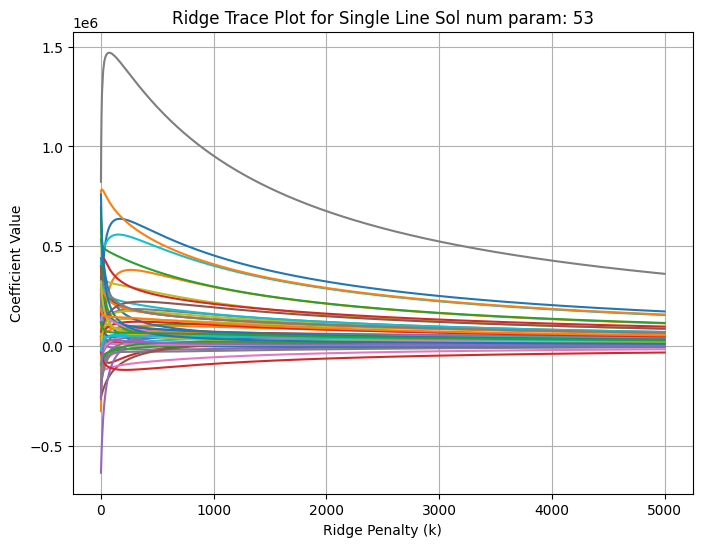

=============================== Trace Plot Two Line Sol ====================================


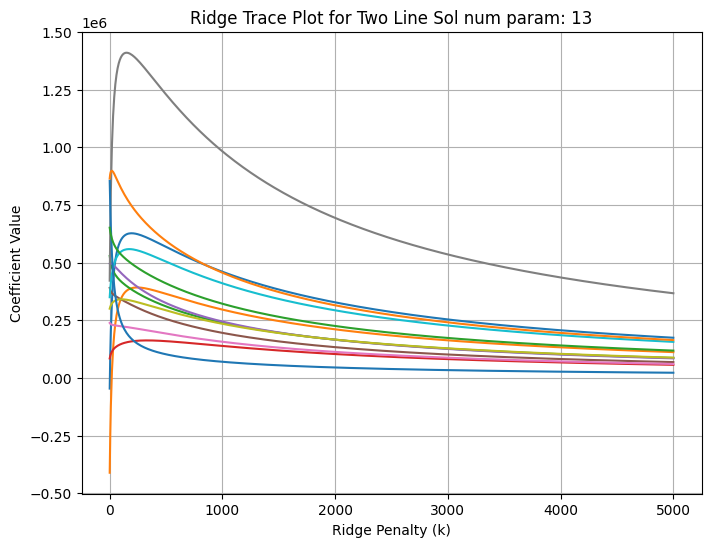

=============================== Trace Plot single Line Sol with box cox ====================


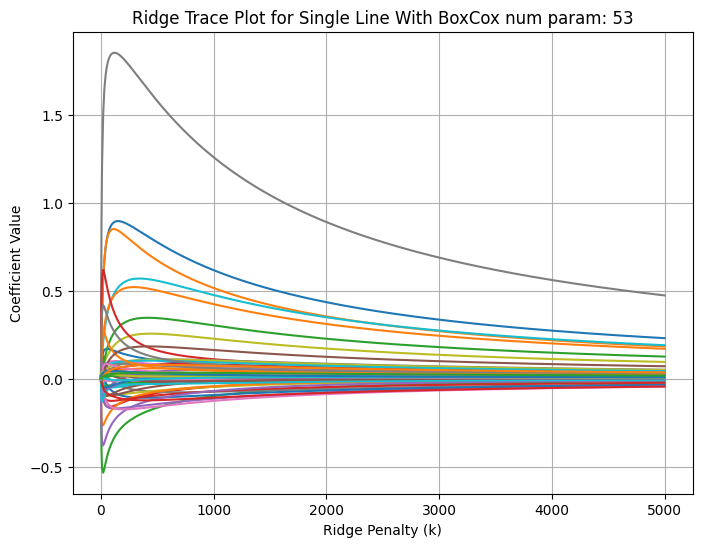

In [9]:
tableDispFormatt('Trace Plot Single Line Sol')
ridef_coff = ridge_coefficients(X_regressor = X_single_sol, 
                   y_dependent = y_single_sol, 
                   k_values = ridge_penalty_param, 
                   fit_intercept=False,
                   scale_coeffs=False)
plot_ridge_trace(riddge_coff_data = ridef_coff.drop(['beta_0'],axis=0),# Drop Intercept term
                 k_values = ridge_penalty_param,
                 models_name = 'Single Line Sol')

tableDispFormatt('Trace Plot Two Line Sol')
ridef_coff = ridge_coefficients(X_regressor = X_two_sol, 
                   y_dependent = y_two_sol, 
                   k_values = ridge_penalty_param, 
                   fit_intercept=False,
                   scale_coeffs=False)
plot_ridge_trace(riddge_coff_data = ridef_coff.drop(['beta_0'],axis=0),# Drop Intercept term
                 k_values = ridge_penalty_param,
                 models_name = 'Two Line Sol')

tableDispFormatt('Trace Plot single Line Sol with box cox')
ridef_coff = ridge_coefficients(X_regressor = X_single_sol_bc, 
                   y_dependent = y_single_sol_bc, 
                   k_values = ridge_penalty_param, 
                   fit_intercept=False,
                   scale_coeffs=False)
plot_ridge_trace(riddge_coff_data = ridef_coff.drop(['beta_0'],axis=0),# Drop Intercept term
                 k_values = ridge_penalty_param,
                 models_name = 'Single Line With BoxCox')

#### What information will get from this plot?

**Coefficient shrinkage**: Each colored line represents one predictor’s coefficient. As k increases, coefficients shrink toward zero. This demonstrates Ridge’s ability to control multicollinearity and prevent extreme coefficient values.

**Stability of coefficients**: At small k, coefficients can vary wildly (unstable estimates). As k grows, the lines flatten, showing coefficients stabilize. The point where coefficients stop changing much indicates a good balance between fit and stability.

**Relative importance of predictors**: Predictors with coefficients that remain relatively large (even after shrinkage) are more influential. Predictors that quickly shrink toward zero contribute less to the model.

**Bias–variance tradeoff**: Small k: low bias, high variance (unstable coefficients). Large k: high bias, low variance (coefficients stable but underfitting). The trace plot helps visualize this tradeoff.

**Model selection insigh**t: By looking at where coefficients stabilize, you can identify a reasonable range for k. This range can then be tested with cross-validation to pick the optimal penalty.

**Ridge Regression Without Transformation**: Coefficients start extremely large (up to ~1.4e6) and shrink as the ridge penalty increases. This suggests the raw target variable (price) has a very skewed distribution, leading to unstable coefficients when no transformation is applied. Ridge regularization helps stabilize, but the scale of coefficients is still problematic. Models trained directly on such raw values may overfit or produce poor generalization.

**Ridge Regression With Box-Cox Transformation**: Coefficients start in a reasonable range (around -0.5 to 1.75) and converge smoothly as ridge penalty increases.The Box-Cox transformation normalizes the target variable, reducing skewness and variance. This makes the regression problem more stable and coefficients more interpretable. This approach is far better for regression tasks, especially when the dependent variable is highly skewed (like housing prices). It improves numerical stability and predictive performance.

Which Approach is Good?

- Box-Cox (or Yeo-Johnson if zeros/negatives exist) → Recommended when the target variable is skewed. It produces stable coefficients and better generalization.
- Plain Ridge Regression → Acceptable if the target is already well-behaved (normally distributed), but not ideal for skewed data like housing prices.




#### Methods for Choosing k:

Much of the **controversy concerning ridge regression centers around the choice of the biasing parameter $k$**. 

Hoerl and Kennard proposed an iterative procedure to determine an optimal biasing parameter $k$ that minimizes the mean squared error (MSE) of the regression coefficients.

**The Iterative Estimation's Procedure Algorithm:**

The method is based on the theoretical formula for \(k\) that minimizes the MSE of the ridge estimator.
Iterative Formulas for Choosing $k$ in Ridge Regression

Step1: Using the ordinary least squares estimator $\hat {\beta }$:

$k=\frac{p\hat {\sigma }^2}{\hat {\beta }'\hat {\beta }}$

Step2: Using the ridge estimator based on $k_0$, denoted $\hat {\beta }_R(k_0)$:

$k_1=\frac{p\hat {\sigma }^2}{\hat {\beta }_R(k_0)'\hat {\beta }_R(k_0)}$

Step3: Using the ridge estimator based on $k_1$, denoted $\hat {\beta }_R(k_1)$:

$k_2=\frac{p\hat {\sigma }^2}{\hat {\beta }_R(k_1)'\hat {\beta }_R(k_1)}$

Step4: Iterate until the value of $k$ stabilizes.

Notations:

Where: 
- $p$ is the number of parameters.
- ${\sigma }^{2}$ is the unbiased estimate of the error variance from the Ordinary Least Squares (OLS) model.
- $\hat {\beta }$: OLS coefficient vector.
- $\hat {\beta }_R(k$): ridge regression coefficient vector for penalty k

It’s a way of converging toward a more stable choice of the ridge penalty parameter.

#### Termination Condition for Iterative Procedure:

The iterative process for updating $k$ is terminated when the relative change between successive values exceeds a threshold:

$\frac{k_{j+1}-k_j}{k_j}>20T^{-1.3}$

- where:
  - $k_j$: current ridge penalty value.
  - $k_{j+1}$: next ridge penalty value.
  - $T$: a parameter (often related to sample size, iterations, or scaling factor depending on context).
  - The inequality ensures that the algorithm stops if the relative change in $k$ is too large compared to the tolerance defined by $20T^{-1.3}$

#### Compute T

$T=\frac{Tr(X^{\prime }X)^{-1}}{P}=\frac{\sum _{j=1}^{p}(1/\lambda _{i})}{p}$

where:
- X is a regressor matrix)
- $\mathrm{Tr}$ is the trace of a matrix,
- $\lambda _j$ are the eigenvalues of X'X,
- $p$ is the number of predictors (columns of X).

#### Qus: Choosing k for Prediction Purposes (Mallows' C_k Statistic) or Hoerl & Kennard (1970) Approach. 
Can we add intercept term in ridge models while apply (Mallows' C_k Statistic) or Hoerl & Kennard?

**Intercept in Ridge Models with Mallows’ $C_k$**:
Ridge regression setup: Normally, ridge regression penalizes all coefficients except the intercept.
When using Mallows’ $C_k$,we should include an intercept term if your data are not mean-centered. The intercept ensures the model accounts for the baseline level of the dependent variable. However, the intercept is not penalized in ridge regression. Penalizing it would distort the baseline prediction and bias the model unnecessarily. If your regressors are centered (mean = 0), the intercept is redundant and can be omitted. If not centered, keep the intercept but exclude it from the ridge penalty. Mallows’ C_k is then computed based on the penalized coefficients only, while the intercept remains free.

Without an intercept, your model may force predictions through the origin, which is rarely realistic in practice (e.g., housing prices are not zero when area = 0). Mallows’ $C_k$ balances bias vs variance. If the intercept were penalized, it would artificially inflate bias and mislead the statistic

Intercept Term in Hoerl & Kennard’s Method:

Just like with Mallows’ $C_k$, the intercept should be included in the model but not penalized. Penalizing the intercept would distort the baseline prediction and bias the model unnecessarily. If predictors are mean-centered, the intercept becomes redundant and can be dropped. If not centered, keep the intercept free while applying ridge penalty only to the other coefficients


#### Final Conclusions:

Always include an intercept unless your predictors are centered.

Do not penalize the intercept when applying ridge regression, whether you’re using Mallows’ $C_k$ or Hoerl & Kennard’s ridge trace method. Use ridge trace plots (Hoerl & Kennard) to visually confirm stability, and Mallows’ $C_k$ to statistically validate predictive performance. In practice, many analysts combine both:
Use ridge trace plots to narrow down a sensible range for k. Use Mallows’ $C_k$ or cross-validation to pick the final $k$

Hoerl & Kennard’s method is more visual/heuristic, Mallows’ C_k is more statistical. Both agree that the intercept should be included but not penalized.

#### Hoerl and Kennard Method Choosing k

#### Hoerl and Kennard Method 1:

In [10]:
def ridge_estimator(X_regressor, y_dependent, k):
    """
    Compute ridge regression coefficients for given k.
    """
    # Ensure numpy arrays
    X_regressor = np.asarray(X_regressor)
    y_dependent = np.asarray(y_dependent).reshape(-1, 1)

    n, p = X_regressor.shape
    I = np.eye(p)
    XtX = X_regressor.T @ X_regressor
    XtY = X_regressor.T @ y_dependent
    beta = np.linalg.inv(XtX + k * I) @ XtY
    return beta.flatten()

def compute_T(X_regressor, tol=1e-12):
    """
    Compute T = Tr((X'X)^-1) / p
    using pseudo-inverse for stability.
    """
    X = np.asarray(X_regressor)
    n, p = X.shape
    
    # Compute X'X
    XtX = X.T @ X
    
    # Method 1: Direct trace of pseudo-inverse
    XtX_inv = np.linalg.pinv(XtX)   # <-- safer than np.linalg.inv
    T_trace = np.trace(XtX_inv) / p
    
    # Method 2: Using eigenvalues, avoid divide by zero
    eigenvalues = np.linalg.eigvals(XtX)
    inv_eigs = [1.0/l if abs(l) > tol else 0.0 for l in eigenvalues]
    T_eigen = np.sum(inv_eigs) / p
    
    return T_trace, T_eigen

def hoerl_kenn_iterative_k_selection(X_regressor, y_dependent,max_iter=100):
    """
    Iteratively compute k using Hoerl-Kennard-Baldwin method with stopping rule.
    """
    T1,T2 = compute_T(X_regressor)
    T = T1
    X_regressor = np.asarray(X_regressor)
    y_dependent = np.asarray(y_dependent)

    n, p = X_regressor.shape
    print(f"Samples {n} predictors {p}")
    # Initial OLS estimate using statsmodels
    ols_model = sm.OLS(y_dependent, X_regressor).fit()
    beta_ols = np.asarray(ols_model.params).reshape(-1, 1)
    #sigma2 = estimate_sigma2(X_regressor, y_dependent, beta_ols)
    sigma2  = ols_model.mse_resid
    # First k0
    k0 = ((p * sigma2) / (beta_ols.T @ beta_ols)).item()
    k_values = [float(k0)]
    
    for j in range(max_iter):
        beta_r = ridge_estimator(X_regressor, y_dependent, k_values[-1])
        k_next = (p * sigma2) / (beta_r.T @ beta_r)
        k_values.append(float(k_next))
        
        # Stopping condition
        rel_change = (k_next - k_values[-2]) / k_values[-2]
        if rel_change > 20 * (T ** -1.3):
            break
    
    return k_values

In [11]:
tableDispFormatt('k value from hoerl_kenn method Model:Single Line Sol with BC')
k_seq = hoerl_kenn_iterative_k_selection(X_regressor = X_single_sol_bc, 
                              y_dependent = y_single_sol_bc,                               
                              max_iter=10)
# Perform element-wise division
k_seq = [k / 2 for k in k_seq]
k_seq = np.round(k_seq,6)
print("Sequence of k values: numpy array:\n", np.array(k_seq).reshape(-1, 1))

tableDispFormatt('k value from hoerl_kenn method Model:Single Line Sol')
k_seq = hoerl_kenn_iterative_k_selection(X_regressor = X_single_sol, 
                              y_dependent = y_single_sol,                               
                              max_iter=10)
# Perform element-wise division
k_seq = [k / 2 for k in k_seq]
k_seq = np.round(k_seq,3)
print("Sequence of k values: numpy array:\n", np.array(k_seq).reshape(-1, 1))

tableDispFormatt('k value from hoerl_kenn method Models: Two Line Sol with bc')
k_seq = hoerl_kenn_iterative_k_selection(X_regressor = X_two_sol_bc, 
                              y_dependent = y_two_sol_bc,                               
                              max_iter=10)
# Perform element-wise division
k_seq = [k / 2 for k in k_seq]
k_seq = np.round(k_seq,3)
print("Sequence of k values: numpy array:\n", np.array(k_seq).reshape(-1, 1))

=============================== k value from hoerl_kenn method Model:Single Line Sol with BC 
Samples 545 predictors 54
Sequence of k values: numpy array:
 [[0.000444]
 [0.000444]
 [0.000444]
 [0.000444]
 [0.000444]
 [0.000444]
 [0.000444]
 [0.000444]
 [0.000444]
 [0.000444]
 [0.000444]]
=============================== k value from hoerl_kenn method Model:Single Line Sol =======
Samples 545 predictors 54
Sequence of k values: numpy array:
 [[1.589]
 [1.848]
 [1.879]
 [1.883]
 [1.883]
 [1.883]
 [1.883]
 [1.883]
 [1.883]
 [1.883]
 [1.883]]
=============================== k value from hoerl_kenn method Models: Two Line Sol with bc 
Samples 545 predictors 14
Sequence of k values: numpy array:
 [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


#### Choosing k for Prediction Purposes (Mallows' C_k Statistic)

The methods of choosing k described thus far are focused on improving the estimates of the regression coefficients. If the model is to be used for prediction purposes, then it may be more appropriate to consider prediction-oriented criteria for choosing $k$.

Colin Mallows introduced the $C_{p}$ **statistic** as a tool for model selection in **OLS**, primarily to balance the trade-off between model bias and model variance. Since Ridge Regression introduces intentional bias to reduce variance, **Mallows' logic was extended** to create the $C_{k}$ statistic (sometimes called $C_{L}$).

The $C_{k}$ statistic allows you to evaluate which value of the penalty parameter $k$ produces the best predictive model.

Mallows (1973) modified the $C_p$ statistic to a $C_k$ statistic that can be used to determine $k$. He proposed plotting $C_k$ against $V_k$, where:

$C_k=\frac{SS_{\mathrm{Res}}(k)}{\hat {\sigma }^2}-n+2+2\, \mathrm{Tr}(XL)$

Where:
- $\mathrm{Tr}$ is the trace of a matrix
- $L=(X'X+kI)^{-1}X'$
- $SS_{Res}$: The Residual Sum of Squares for the ridge model with penalty $k (y-X\^{\beta }_{k})^{2}$. This is the functions of $k$. Suggested to that choose $k$ to minimized $C_k$. 
- $\hat \sigma^{2}$: The unbiased estimate of the error variance (usually taken from the full OLS model).
- $n$: The number of observations.

$V_k$:
- $V_k=1+\mathrm{Tr}(X'XL')$

Here, $SS_{\mathrm{Res}}(k)$ is the residual sum of squares as a function of $k$. The suggestion is to choose $k$ that minimizes $C_k$.

#### Hat Matrix $H_{k}$ & The Role of the Hat Matrix $H_{k}$:

$XL+X(X'X+kI)^{-1}X'=H_k$

This $H_k$ is the ridge regression hat matrix, equivalent to the hat matrix in **ordinary least squares** hat matrix but adjusted for the penalty $k$.

Look for small $C_{k}$ values: A good model will have a low $C_{k}$ value, indicating low prediction error.

Target $C_{k}\approx V_{k}$: Ideally, you look for a point where the $C_{k}$ value is close to the corresponding $V_{k}$ value. There is often a diagonal line drawn on the plot to help visualize this. Models near this line are considered relatively unbiased in estimating the true regression coefficients.


In [12]:
def ridge_hat_matrix(X_regressor: np.ndarray, k: float) -> np.ndarray:
    """
    Compute the ridge regression hat matrix H_k = X (X'X + kI)^(-1) X'.
    Returns
    -------
    H_k : np.ndarray
        Hat matrix of shape (n, n).
    """
    # Ensure X is numpy array
    X = np.asarray(X_regressor)
    
    # Dimensions
    n, p = X.shape
    
    # Compute (X'X + kI)^(-1)
    XtX = X.T @ X
    ridge_term = XtX + k * np.eye(p)
    ridge_inv = np.linalg.inv(ridge_term)
    
    # Hat matrix
    H_k = X @ ridge_inv @ X.T
    return H_k

def compute_Ck_Vk_Hk(X_regressor, y_dependent, k_values, tol=1e-12):
    """
    Compute C_k, V_k, and H_k for a range of ridge penalty values.
    
    Parameters
    ----------
    X_regressor : numpy.ndarray
        Regressor matrix (n, p)
    y_dependent : numpy.ndarray
        Dependent variable vector (n,)
    k_values : list or array
        Ridge penalty values
    tol : float
        Tolerance for eigenvalue stability
    
    Returns
    -------
    results : dict
        Dictionary with keys 'Ck', 'Vk', 'Hk' (each a list for each k)
    """
    X__ = np.asarray(X_regressor)
    y__ = np.asarray(y_dependent).reshape(-1, 1)
    n, p = X__.shape
    
    # OLS model for sigma^2 estimate
    ols_model = sm.OLS(y__, X__).fit()
    #sigma2_hat = np.mean(ols_model.resid**2)
    sigma2_hat = ols_model.mse_resid
    Ck_list, Vk_list, Hk_list,e_ik_list = [], [], [], []
    XtX = X__.T @ X__
    for k in k_values:        
        XtX_inv_k = np.linalg.pinv(XtX + k*np.eye(p))  # safer than inv
        
        # Define L and L'
        L = XtX_inv_k @ X__.T              # (p, n)
        LtL = L @ L.T          # (n, p)       
        
        # Ridge coefficients
        beta_r = XtX_inv_k @ (X__.T @ y__)
        
        # Residuals for ridge
        y_hat = X__ @ beta_r
        residuals = y__ - y_hat
        SS_res = (residuals.T @ residuals).item()  # safe scalar
        e_ik_list.append(residuals)
        # Compute C_k
        Ck = (SS_res / sigma2_hat) - n + 2 + 2 * np.trace(X__ @ L)
        Ck_list.append(Ck)
        
        # Compute V_k (correct formula using L')
        Vk = 1 + np.trace(XtX @ LtL)
        Vk_list.append(Vk)
        
        # Compute H_k
        # Hk = X__ @ L + X__ @ XtX_inv_k @ X__.T
        Hk = ridge_hat_matrix(X_regressor=X_regressor, k=k) 
        Hk_list.append(Hk)
    
    return {"Ck": Ck_list, "Vk": Vk_list, "Hk": Hk_list,"e_ik_list":e_ik_list}

def plot_Ck_Vk(Ck_list, Vk_list, k_values):
    """
    Plot C_k vs V_k for given k values.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(Vk_list, Ck_list, marker='o')
    #for i, k in enumerate(k_values):
    #    plt.text(Vk_list[i], Ck_list[i], f"k={k}", fontsize=8)
    
    plt.xlabel("V_k")
    plt.ylabel("C_k")
    plt.title("Mallows C_k vs V_k Plot")
    plt.grid(True)
    plt.show()

def plot_X_Ck_Vk(Ck_list, Vk_list, k_values, threshold=None, font_size=9,models_name = ''):
    """
    Plot C_k vs V_k for given k values and annotate smaller C_k values.
    
    Parameters
    ----------
    Ck_list : list
        List of C_k values
    Vk_list : list
        List of V_k values
    k_values : list
        Ridge penalty values corresponding to C_k and V_k
    threshold : float, optional
        Annotate points where C_k <= threshold. If None, annotate the lowest 3 values.
    font_size : int, optional
        Font size for annotation text (default=9)
    """   
    
    plt.figure(figsize=(8, 6))
    plt.plot(Ck_list,Vk_list, marker='o', linestyle='-', color='blue')
    plt.xlabel("C_k")
    plt.ylabel("V_k")
    plt.title(f"{models_name} Mallows C_k vs V_k Plot")
    plt.grid(True)
    
    # Decide which points to annotate
    if threshold is not None:
        indices_to_annotate = [i for i, ck in enumerate(Ck_list) if ck <= threshold]
    else:
        # Annotate the 3 smallest Ck values
        indices_to_annotate = np.argsort(Ck_list)[:3]
    for i in indices_to_annotate:
        print(f'k value for min C_k & V_k: {k_values[i]}')
    # Annotate selected points
    for i in indices_to_annotate:
        plt.annotate(f"k={k_values[i]}, Ck={Ck_list[i]:.2f}",
                     xy=(Vk_list[i], Ck_list[i]),
                     xytext=(Vk_list[i]+2, Ck_list[i] + 10),
                     textcoords='data',
                     ha='center',
                     fontsize=12,
                     arrowprops=dict(arrowstyle='->', color='red'))    
    plt.show()



=============================== One Line Sol with box cox ==================================
minum of C_k 56.344241655529586  minum of v_k 1.3148319315814216
k value for min C_k & V_k: 0.01
k value for min C_k & V_k: 0.1
k value for min C_k & V_k: 0.2


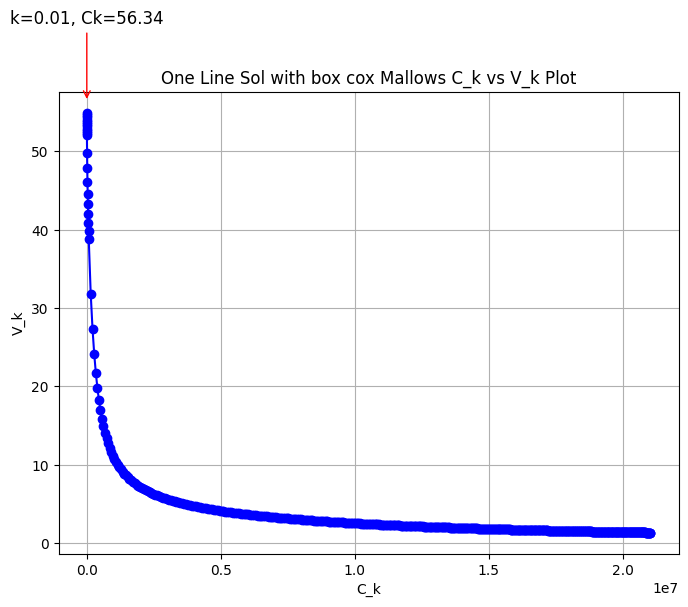

=============================== One Line Sol ===============================================
minum of C_k 50.582900228120906  minum of v_k 1.3148319315814216
k value for min C_k & V_k: 5
k value for min C_k & V_k: 6
k value for min C_k & V_k: 4


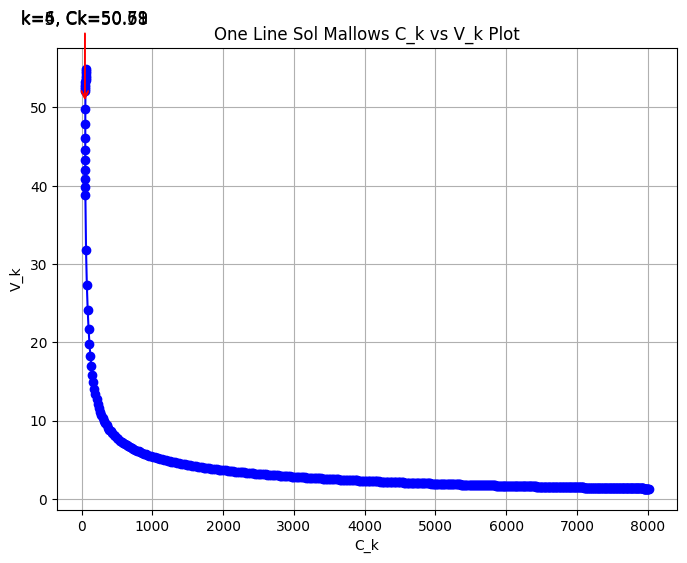

=============================== Two Line Sol with bc =======================================
minum of C_k 16.14000377219676  minum of v_k 1.1042641534164224
k value for min C_k & V_k: 0.01
k value for min C_k & V_k: 0.1
k value for min C_k & V_k: 0.2


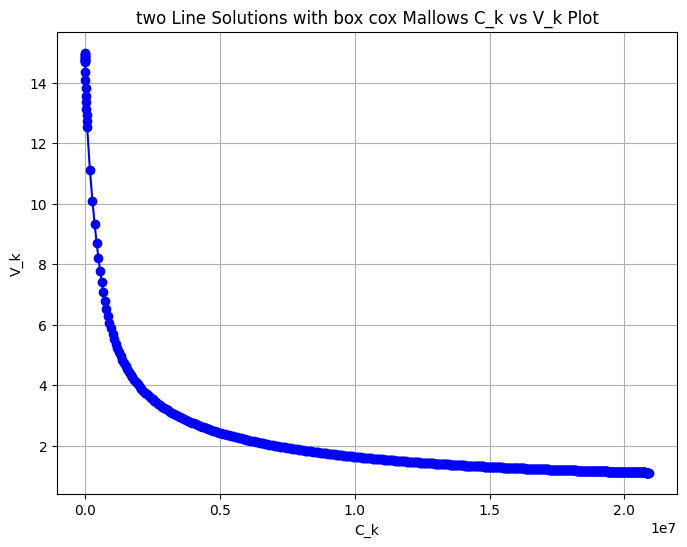

In [13]:
results_compute_Ck_Vk_Hk = compute_Ck_Vk_Hk(X_regressor = X_single_sol_bc, 
                           y_dependent = y_single_sol_bc, 
                           k_values    = ridge_penalty_param
                           )
tableDispFormatt('One Line Sol with box cox')
print(f'minum of C_k',min(results_compute_Ck_Vk_Hk["Ck"]),' minum of v_k',min(results_compute_Ck_Vk_Hk["Vk"]))
plot_X_Ck_Vk(Ck_list  = results_compute_Ck_Vk_Hk["Ck"], 
           Vk_list  = results_compute_Ck_Vk_Hk["Vk"], 
           k_values = ridge_penalty_param,
           models_name='One Line Sol with box cox'
           )

results_compute_Ck_Vk_Hk = compute_Ck_Vk_Hk(X_regressor = X_single_sol, 
                           y_dependent = y_single_sol, 
                           k_values    = ridge_penalty_param
                           )
tableDispFormatt('One Line Sol')
print(f'minum of C_k',min(results_compute_Ck_Vk_Hk["Ck"]),' minum of v_k',min(results_compute_Ck_Vk_Hk["Vk"]))
plot_X_Ck_Vk(Ck_list  = results_compute_Ck_Vk_Hk["Ck"], 
           Vk_list  = results_compute_Ck_Vk_Hk["Vk"], 
           k_values = ridge_penalty_param,
           models_name='One Line Sol'
           )

results_compute_Ck_Vk_Hk = compute_Ck_Vk_Hk(X_regressor = X_two_sol_bc, 
                           y_dependent = y_two_sol_bc, 
                           k_values    = ridge_penalty_param
                           )
tableDispFormatt('Two Line Sol with bc')
print(f'minum of C_k',min(results_compute_Ck_Vk_Hk["Ck"]),' minum of v_k',min(results_compute_Ck_Vk_Hk["Vk"]))
plot_X_Ck_Vk(Ck_list  = results_compute_Ck_Vk_Hk["Ck"], 
           Vk_list  = results_compute_Ck_Vk_Hk["Vk"], 
           k_values = ridge_penalty_param,
           models_name='two Line Solutions with box cox'
           )

#### Choosing optimal $k$ by use PRESS Ridge Procedure

The Ridge Hat Matrix $H_{k}$:The Ridge Hat matrix is defined in the text's equation as: 

$H_{k}=XL+X(X^{\prime }X+kI)^{-1}X^{\prime }$

(Note: The first term "$XL$" appears to be a typo in the original text/image content, as the standard formula is given by the rest of the expression).

This matrix maps the vector of observed responses $y$ to the vector of fitted values $\hat {y}_{k}$.

The text notes that $H_{k}$ is equivalent to the hat matrix in ordinary least squares when $k=0$. The diagonal elements $h_{ii,k}$ are the leverages, representing the influence of each observation on its own prediction.

The PRESS Ridge Procedure:

$PRESS$ stands for Prediction Error Sum of Squares. It is an out-of-sample validation statistic that estimates a model's predictive performance.

The image presents an approximation of the true $PRESS$ value for Ridge Regression:

$\mathrm{PRESS_{Ridge}}(k)=\sum _{i=1}^n\left( \frac{e_{i,k}}{1-h_{ii,k}}\right) ^2$

Where:

- $e_{i,k}$: $i^{th}$ residual (observed minus predicted value) for the model with penalty $k$.
- $h_{ii,k}$: diagonal element of the ridge hat matrix $H_k=X(X'X+kI)^{-1}X'$.
- Choose $k$ that minimizes $PRESS{}_{\mathrm{Ridge}}$.

#### Determining the optimal $k$:

The value of $k$ is chosen so as to minimize the calculated $\text{PRESS}_{\text{Ridge}}$ statistic. This value provides the best trade-off between the bias introduced by regularization and the reduction in variance, leading to better predictions on new data.

Note on Approximation The text points out that this formula is only an approximation of the exact PRESS value (Equation 2 in the image) that would be obtained by standard Leave-One-Out Cross-Validation (LOOCV). The approximation is computationally much faster because it avoids refitting the model $n$ times but works best when there are no highly influential data points (large leverages).

In [14]:
def compute_PRESS_ridge(X_regressor, y_dependent, k_values):
    """
    Compute PRESS_Ridge for a range of ridge penalty values.
    
    Parameters
    ----------
    X_regressor : numpy.ndarray
        Regressor matrix (n, p)
    y_dependent : numpy.ndarray
        Dependent variable vector (n,)
    k_values : list or array
        Ridge penalty values
    
    Returns
    -------
    press_list : list
        PRESS_Ridge values for each k
    """
    X = np.asarray(X_regressor)
    y = np.asarray(y_dependent).reshape(-1, 1)
    n, p = X.shape
    
    press_list = []
    XtX = X.T @ X
    for k in k_values:
        
        XtX_inv_k = np.linalg.pinv(XtX + k*np.eye(p))  # pseudo-inverse for stability
        
        # Hat matrix H_k
        #Hk = X @ XtX_inv_k @ X.T
        Hk = ridge_hat_matrix(X_regressor = X_regressor, k = k)
        # Ridge coefficients
        beta_r = XtX_inv_k @ (X.T @ y)
        
        # Residuals
        y_hat = X @ beta_r
        residuals = (y - y_hat).flatten()
        
        # Diagonal of H_k
        h_diag = np.diag(Hk)
        
        # PRESS_Ridge
        press_k = np.sum((residuals / (1 - h_diag))**2)
        press_list.append(press_k)
    
    return press_list

def plot_PRESS_ridge(k_values, press_list,model_name = ''):
    """
    Plot PRESS_Ridge vs k.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, press_list, marker='o', linestyle='-')
    plt.xlabel("Ridge Penalty k")
    plt.ylabel("PRESS_Ridge")    
    plt.grid(True)
    
    # Highlight the minimum PRESS
    min_idx = np.argmin(press_list)
    plt.scatter(k_values[min_idx], press_list[min_idx], color='red', zorder=5)
    optimal_k = k_values[min_idx]
    print(f"Optimal k = {optimal_k}")
    plt.title(f"Model {model_name} PRESS Ridge vs k={optimal_k}")
    optimal_press = press_list[min_idx]
    plt.annotate(f"Optimal k = {optimal_k}",
                 xy=(optimal_k, optimal_press),
                 xytext=(optimal_k, optimal_press + 100),
                 textcoords='data',
                 ha='center',
                 fontsize=11,
                 arrowprops=dict(arrowstyle='->', color='red'))    
    plt.show()


Optimal k = 7


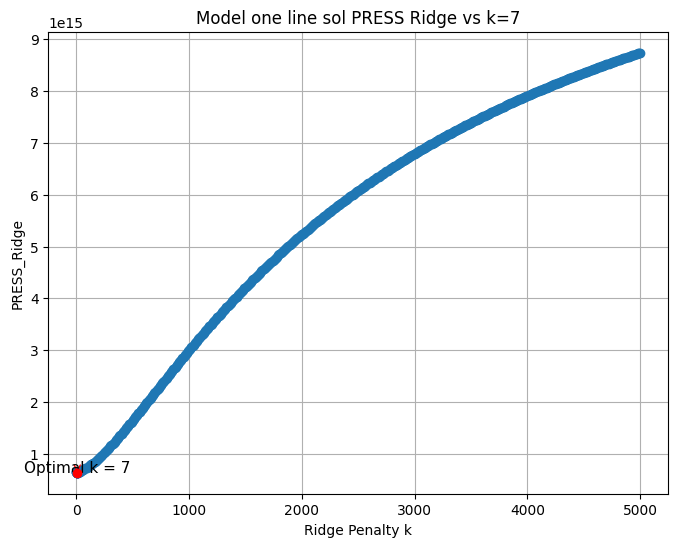

Optimal k = 0.01


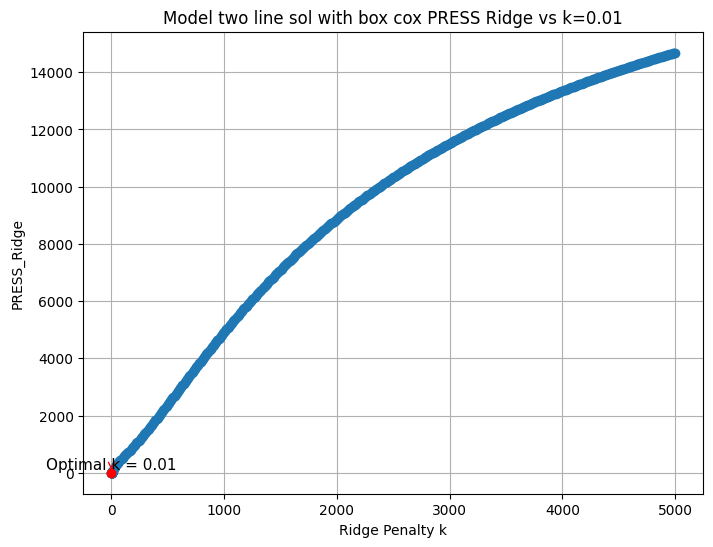

Optimal k = 0.01


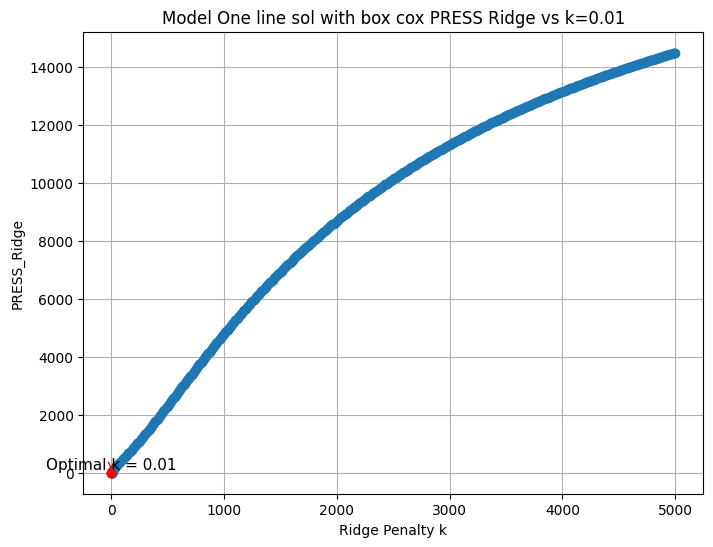

In [15]:
press_values = compute_PRESS_ridge(X_regressor = X_single_sol, 
                                   y_dependent = y_single_sol, 
                                   k_values    = ridge_penalty_param
                                   )
#for k, press in zip(ridge_penalty_param, press_values):
#    print(f"k={k}, PRESS_Ridge={press:.4f}")
plot_PRESS_ridge(k_values = ridge_penalty_param, 
                 press_list = press_values,
                 model_name = 'one line sol')

press_values = compute_PRESS_ridge(X_regressor = X_two_sol_bc, 
                                   y_dependent = y_two_sol_bc, 
                                   k_values    = ridge_penalty_param
                                   )
#for k, press in zip(ridge_penalty_param, press_values):
#    print(f"k={k}, PRESS_Ridge={press:.4f}")
plot_PRESS_ridge(k_values = ridge_penalty_param, 
                 press_list = press_values,
                 model_name = 'two line sol with box cox')

press_values = compute_PRESS_ridge(X_regressor = X_single_sol_bc, 
                                   y_dependent = y_single_sol_bc, 
                                   k_values    = ridge_penalty_param
                                   )
#for k, press in zip(ridge_penalty_param, press_values):
#    print(f"k={k}, PRESS_Ridge={press:.4f}")
plot_PRESS_ridge(k_values = ridge_penalty_param, 
                 press_list = press_values,
                 model_name = 'One line sol with box cox')

#### Generalized Cross‑Validation (GCV) in ridge regression.

In ridge regression, Generalized Cross-Validation (GCV) is an efficient statistical technique used to select the optimal regularization parameter $\lambda$ or $\alpha$. It acts as a computationally faster approximation of Leave-One-Out Cross-Validation (LOOCV), providing a reliable estimate of a model's predictive risk without needing to retrain the model for every single data point.

The primary goal of GCV is to balance the bias‑variance tradeoff. By finding the value of $\lambda$  that minimizes the $GCV$ score, you ensure the model is complex enough to capture patterns but simple enough to avoid overfitting.

The Smoother/Hat Matrix $GCV$ relies on the hat matrix $S_{\lambda }$ (also called the smoothing matrix), which maps the observed response values to the predicted values.

Rotation Invariance: Unlike some other cross‑validation methods, GCV is rotation‑invariant, meaning it remains consistent even if the coordinate system of the data is transformed.

Generalized Cross‑Validation (GCV) Score:

$GCV(\lambda )=\frac{\frac{1}{n}\sum _{i=1}^n(y_i-\hat {y}_i)^2}{\left( 1-\frac{1}{n}\, \mathrm{tr}(S_{\lambda })\right) ^2}$

Explanation
- $n$: number of data points.
- $\sum (y_i-\hat {y}_i)^2$: Residual Sum of Squares (RSS), measuring how far predictions are from actual values.
- $\mathrm{tr}(S_{\lambda })$: the trace of the hat (or smoothing) matrix, which represents the effective degrees of freedom used by the model.

Matrix Form:

$\mathrm{GCV}(k)=\frac{\sum _{i=1}^ne_{i,k}^2}{\left\{ n-\left[ 1+\mathrm{Tr}(H_k)\right] \right\} ^2}$
- $e_{i,k}$: residual for observation i at ridge penalty k.
- $H_k$: the ridge regression hat matrix.
- $\mathrm{Tr}(H_k)$: the trace of the hat matrix, which measures the effective degrees of freedom used by the model.
- $n$: number of observations.

- PRESS requires recomputing the model for each left‑out observation → expensive.
- GCV is a computational shortcut that uses the hat matrix trace to approximate PRESS.
- ***Choose $k$ (the ridge penalty) that minimizes GCV***, giving the best balance between fit and complexity

In [16]:
def compute_GCV_ridge(X_regressor, y_dependent, k_values):
    """
    Compute GCV for ridge regression across a range of k values.
    Returns
    -------
    gcv_list : list
        GCV values for each k
    """
    X = np.asarray(X_regressor)
    y = np.asarray(y_dependent).reshape(-1, 1)
    n, p = X.shape
    XtX = X.T @ X

    gcv_list = []    
    for k in k_values:
        
        XtX_inv_k = np.linalg.pinv(XtX + k*np.eye(p))  # pseudo-inverse for stability
        
        # Hat matrix H_k
        Hk = X @ XtX_inv_k @ X.T
        
        # Ridge coefficients
        beta_r = XtX_inv_k @ (X.T @ y)
        
        # Residuals
        y_hat = X @ beta_r
        residuals = (y - y_hat).flatten()
        
        # Residual sum of squares
        rss = np.sum(residuals**2)
        
        # Trace of hat matrix
        tr_Hk = np.trace(Hk)
        
        # GCV formula
        gcv_k = rss / (n - (1 + tr_Hk))**2
        gcv_list.append(gcv_k)
    
    return gcv_list

def plot_GCV_ridge(k_values, gcv_list,model_name = ''):
    """
    Plot GCV vs k with annotation for optimal k.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, gcv_list, marker='o', linestyle='-', color='green', label='GCV')
    plt.xlabel("Ridge Penalty k")
    plt.ylabel("GCV")    
    plt.grid(True)

    # Highlight the minimum GCV
    min_idx = np.argmin(gcv_list)
    optimal_k = k_values[min_idx]
    optimal_gcv = gcv_list[min_idx]
    print(f"Optimal k = {optimal_k} optimal gcv {optimal_gcv}")
    plt.title(f"{model_name} GCV vs Ridge Penalty k={optimal_k}")
    plt.scatter(optimal_k, optimal_gcv, color='red', zorder=5, label='Optimal k')
    plt.annotate(f"Optimal k = {optimal_k}",
                 xy=(optimal_k, optimal_gcv),
                 xytext=(optimal_k, optimal_gcv + 0.05*optimal_gcv),
                 textcoords='data',
                 ha='center',
                 fontsize=16,
                 arrowprops=dict(arrowstyle='->', color='red'))

    plt.legend()
    plt.tight_layout()
    plt.show()

Optimal k = 5 optimal gcv 2046119854.4508176


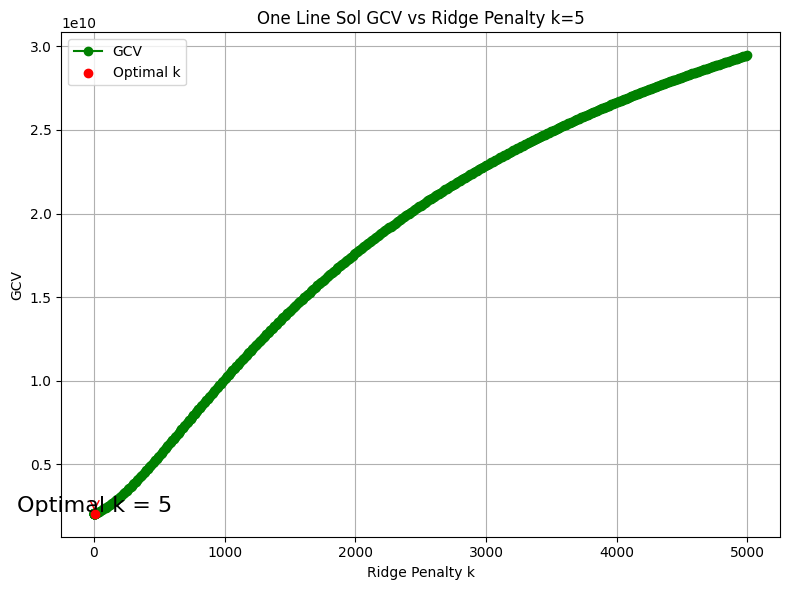

Optimal k = 0.01 optimal gcv 1.3236282842852238e-06


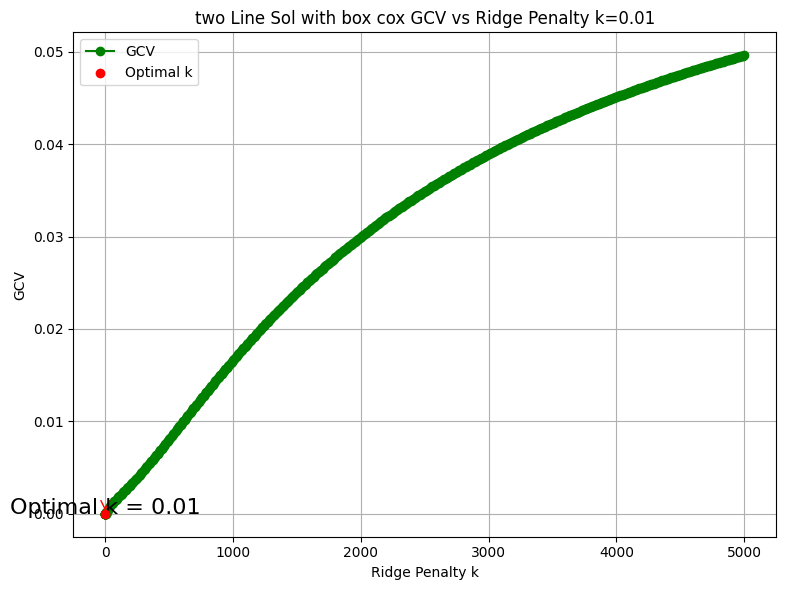

Optimal k = 0.01 optimal gcv 1.3996113374236137e-06


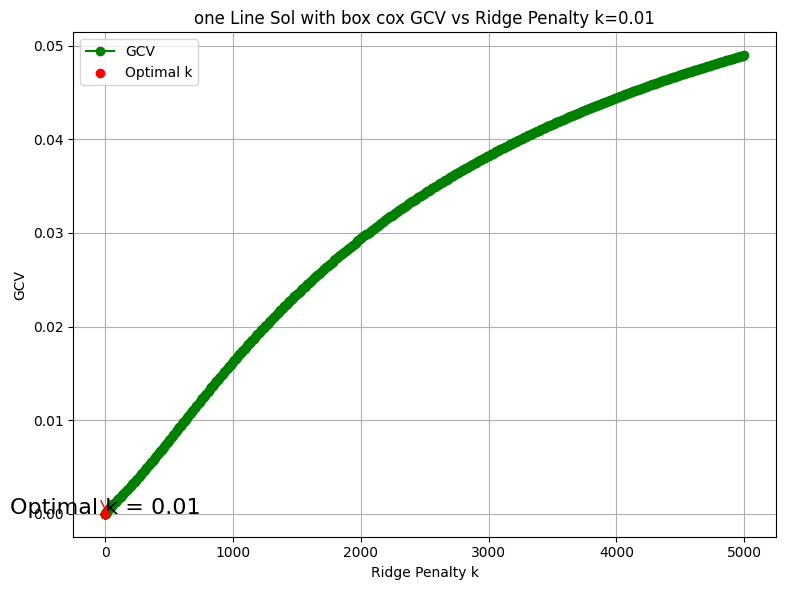

In [17]:
# Compute GCV
gcv_values = compute_GCV_ridge(X_regressor = X_single_sol, 
                                   y_dependent = y_single_sol, 
                                   k_values    = ridge_penalty_param)

# Plot GCV vs k
plot_GCV_ridge(k_values = ridge_penalty_param, 
               gcv_list = gcv_values,
               model_name='One Line Sol')

# Compute GCV
gcv_values = compute_GCV_ridge(X_regressor = X_two_sol_bc, 
                                   y_dependent = y_two_sol_bc, 
                                   k_values    = ridge_penalty_param)

# Plot GCV vs k
plot_GCV_ridge(k_values = ridge_penalty_param, 
               gcv_list = gcv_values,
               model_name='two Line Sol with box cox')

# Compute GCV
gcv_values = compute_GCV_ridge(X_regressor = X_single_sol_bc, 
                                   y_dependent = y_single_sol_bc, 
                                   k_values    = ridge_penalty_param)

# Plot GCV vs k
plot_GCV_ridge(k_values = ridge_penalty_param, 
               gcv_list = gcv_values,
               model_name = 'one Line Sol with box cox')

![optimum_k_value](image-5.png)

We can clearly observe that ridge regression models combined with Box-Cox transformations yield lower values of the penalty parameter $k$. According to theoretical guidance, the appropriate range for $k$ lies between $0<k<1$. Therefore, for further analysis we will focus only on two models:
- The one-line solution model with Box-Cox transformation
- The two-line solution model with Box-Cox transformation
In both cases, we will select the optimum value of $k$ as determined through the Box-Cox transformed models.

optimum_k_one_lin_sol_bc =  [0.01,0.2,0.000444]

optimum_k_two_line_sol_bc = [ 0.6,0.8,0.5,0.7,0.43,0.44,0.45]

$\mathrm{Mean}=\frac{0.6+0.8+0.5+0.7}{4}$

$\mathrm{Mean}=\frac{2.6}{4}=0.65$

$\mathrm{Mean}=\frac{0.43+0.44+0.45}{3}$

$\mathrm{Mean}=\frac{1.32}{3}=0.44$

optimum_k_two_line_sol_bc = [0.44,0.65]



#### Ridge Confidance Interval Plot:

TODO Getting some issue.

In [18]:
def get_prediction(beta_ridge: pd.Series, X_regressor: np.ndarray, y: pd.Series):
    """
    OLS-style prediction function for Ridge regression.
    
    Parameters
    ----------
    beta_ridge : pd.Series
        Ridge regression coefficients (length p).
    X_regressor : np.ndarray
        Scaled design matrix (n x p).
    y : pd.Series
        Dependent variable (n,).
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - 'y_true' : actual values
        - 'y_pred' : predicted values
        - 'residuals' : y_true - y_pred
    """
    # Ensure y is numpy vector
    y_true = y.values.flatten()
    
    # Predictions
    y_pred = X_regressor @ beta_ridge.values
    
    # Residuals
    residuals = y_true - y_pred
    
    # Return DataFrame
    results = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "residuals": residuals
    })
    
    return results
# Example plotting
def plot_ridge_predictions(x, y, pred_df, ci_df, bootstrapping=True):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(x, y, "o", label="data")
    ax.plot(x, pred_df["y_true"], "b-", label="True")
    ax.plot(x, pred_df["y_pred"], "b--.", label="Ridge")
    if bootstrapping:
        ax.plot(x, ci_df["Bootstrap_CI_Upper"].reindex(pred_df.index), "r--", label="CI Upper")
        ax.plot(x, ci_df["Bootstrap_CI_Lower"].reindex(pred_df.index), "k--", label="CI Lower")
    else:
        ax.plot(x, ci_df["Analytical_CI_Upper"].reindex(pred_df.index), "r--", label="CI Upper")
        ax.plot(x, ci_df["Analytical_CI_Lower"].reindex(pred_df.index), "r--", label="CI Lower")
    ax.legend(loc="best")
    plt.show()
    
def ridge_confidence_intervals(
    X_regressor: np.ndarray,
    y_dependent_var: pd.Series,
    beta_ridge: pd.Series,
    k: float,
    alpha: float = 0.05,
    n_bootstrap: int = 1000
):
    """
    Compute confidence intervals for Ridge regression coefficients.
    Returns
    -------
    pd.DataFrame
        DataFrame with coefficient estimates and confidence intervals:
        - 'Coefficient'
        - 'Analytical_CI_Lower'
        - 'Analytical_CI_Upper'
        - 'Bootstrap_CI_Lower'
        - 'Bootstrap_CI_Upper'
    """
    # Ensure y is numpy vector
    y = y_dependent_var.values.flatten()
    n, p = X_regressor.shape

    # Residuals and sigma^2
    resid = y - X_regressor @ beta_ridge.values
    sigma2 = np.mean(resid**2)

    # Analytical variance
    XtX = X_regressor.T @ X_regressor
    var_matrix = sigma2 * np.linalg.inv(XtX + k*np.eye(p)) @ XtX @ np.linalg.inv(XtX + k*np.eye(p))
    se = np.sqrt(np.diag(var_matrix))

    z_val = norm.ppf(1 - alpha/2)
    ci_lower_analytical = beta_ridge.values - z_val * se
    ci_upper_analytical = beta_ridge.values + z_val * se

    # Bootstrap confidence intervals
    boot_coefs = []
    for _ in range(n_bootstrap):
        Xb, yb = resample(X_regressor, y)
        # Ridge estimator formula directly
        beta_boot = np.linalg.inv(Xb.T @ Xb + k*np.eye(p)) @ (Xb.T @ yb)
        boot_coefs.append(beta_boot)
    boot_coefs = np.array(boot_coefs)

    ci_lower_boot = np.percentile(boot_coefs, 100*alpha/2, axis=0)
    ci_upper_boot = np.percentile(boot_coefs, 100*(1-alpha/2), axis=0)

    # Combine results
    results = pd.DataFrame({
        "Coefficient": beta_ridge.values,
        "Analytical_CI_Lower": ci_lower_analytical,
        "Analytical_CI_Upper": ci_upper_analytical,
        "Bootstrap_CI_Lower": ci_lower_boot,
        "Bootstrap_CI_Upper": ci_upper_boot
    }, index=beta_ridge.index)

    return results

In [19]:
values = [
    0.000444, 0.01, 0.1, 0.2, 0.43, 0.44, 0.45,
    0.5, 0.6, 0.7, 0.8, 1.589, 1.848, 1.879, 1.883,
    5.0, 6.0, 7.0
]

# Remove duplicates while keeping sorted order
unique_sorted_values = list(dict.fromkeys(values))

print("Unique sorted values:")
print(unique_sorted_values)


Unique sorted values:
[0.000444, 0.01, 0.1, 0.2, 0.43, 0.44, 0.45, 0.5, 0.6, 0.7, 0.8, 1.589, 1.848, 1.879, 1.883, 5.0, 6.0, 7.0]


In [20]:
optimum_k_one_lin_sol_bc =  [0.000444,0.01,0.2]
optimum_k_two_line_sol_bc = [0.44,0.65]
optimum_k_concidered_all = unique_sorted_values

In [21]:
ridge_x_regressor = X_single_sol_bc
ridge_y_regressor = y_single_sol_bc

ridef_coff_one_sol_bc = ridge_coefficients(X_regressor = ridge_x_regressor, 
                   y_dependent = ridge_y_regressor, 
                   k_values = optimum_k_one_lin_sol_bc, 
                   fit_intercept=False,
                   scale_coeffs=False)

ridge_cofficient  = ridef_coff_one_sol_bc[0.000444]

pred_df = get_prediction(beta_ridge = ridge_cofficient, 
               X_regressor = ridge_x_regressor, 
               y = ridge_y_regressor)

ci_df = ridge_confidence_intervals(
    X_regressor=ridge_x_regressor,
    y_dependent_var=ridge_y_regressor,
    beta_ridge=ridge_cofficient,
    k=0.000444,
    alpha=0.05,
    n_bootstrap=500
)

# Plot TODO
#plot_ridge_predictions(
#    x=ridge_x_regressor,
#    y=ridge_y_regressor,
#    pred_df=pred_df,
#    ci_df=ci_df,
#    bootstrapping=False)

In [22]:
def ridge_mse(X_regressor: np.ndarray, y_dependent_variable: pd.DataFrame, k_list: list):
    """
    Calculate MSE of Ridge regression estimator for given penalty parameters.
    
    Parameters
    ----------
    X_regressor : np.ndarray
        Scaled design matrix (n x p).
    y_dependent_variable : pd.DataFrame
        Response vector (n x 1).
    k_list : list
        List of ridge penalty parameters.
    
    Returns
    -------
    pd.DataFrame
        DataFrame with columns:
        - 'Penalty' : ridge penalty parameter (k)
        - 'MSE'     : corresponding MSE value
    """
    # Ensure y is numpy vector
    y = y_dependent_variable.values.flatten()
    
    # OLS estimates
    XtX = X_regressor.T @ X_regressor
    XtY = X_regressor.T @ y
    beta_ols = np.linalg.pinv(XtX) @ XtY
    
    # Residuals and sigma^2 (OLS MSE of residuals)
    resid = y - X_regressor @ beta_ols
    sigma2 = np.mean(resid**2)
    
    # Eigen decomposition of XtX
    eigvals, _ = np.linalg.eigh(XtX)
    
    results = []
    for k in k_list:
        # First term: variance component
        var_term = sigma2 * np.sum(eigvals / (eigvals + k)**2)
        
        # Second term: bias component
        bias_term = (k**2) * (beta_ols @ beta_ols) / np.sum((eigvals + k)**2)
        
        mse_val = var_term + bias_term
        results.append((k, mse_val))
    
    # Convert to DataFrame
    mse_df = pd.DataFrame(results, columns=["Penalty", "MSE"])    
    return mse_df

def plot_ridge_mse(mse_df: pd.DataFrame, penalty_team: list = None,model_name = ''):
    """
    Plot Penalty vs MSE with a marker at the optimal penalty.
    Also annotate penalties provided in penalty_team list with red arrows.
    
    Parameters
    ----------
    mse_df : pd.DataFrame
        DataFrame with columns ['Penalty','MSE'].
    penalty_team : list, optional
        List of penalty values to annotate on the plot.
    """
    plt.figure(figsize=(8,5))
    plt.plot(mse_df["Penalty"], mse_df["MSE"], marker="o", linestyle="-", color="blue")
    plt.xlabel("Ridge Penalty (k)")
    plt.ylabel("MSE")
    plt.title(f"{model_name} Penalty vs MSE for Ridge Regression")

    # Highlight optimal penalty
    min_idx = mse_df["MSE"].idxmin()
    optimal_k = mse_df.loc[min_idx, "Penalty"]
    optimal_mse = mse_df.loc[min_idx, "MSE"]
    plt.axvline(x=optimal_k, color="red", linestyle="--", label=f"Optimal k = {optimal_k:.3f}")
    plt.scatter([optimal_k], [optimal_mse], color="red")
    plt.annotate(f"Optimal k = {optimal_k:.3f}",
                 #xy=(optimal_k, optimal_mse),
                 xy=(0.001, 0.001),
                 xytext=(optimal_k, optimal_mse),
                 arrowprops=dict(facecolor="red", shrink=0.05, width=1.5))

    # Annotate penalty_team values with red arrows
    if penalty_team is not None:
        for i,p in enumerate(penalty_team):            
            if p in mse_df["Penalty"].values:
                mse_val = mse_df.loc[mse_df["Penalty"] == p, "MSE"].values[0]
                plt.scatter([p], [mse_val], color="green")
                plt.annotate(f"k={p}",
                             xy=(p, mse_val),
                             xytext=(p, (mse_val)),
                             arrowprops=dict(facecolor="red", shrink=0.05, width=1.5))

    plt.legend()
    plt.grid(True)
    plt.show()

#### Plot Ridge MSE for One line solutions with Box Cox transformations

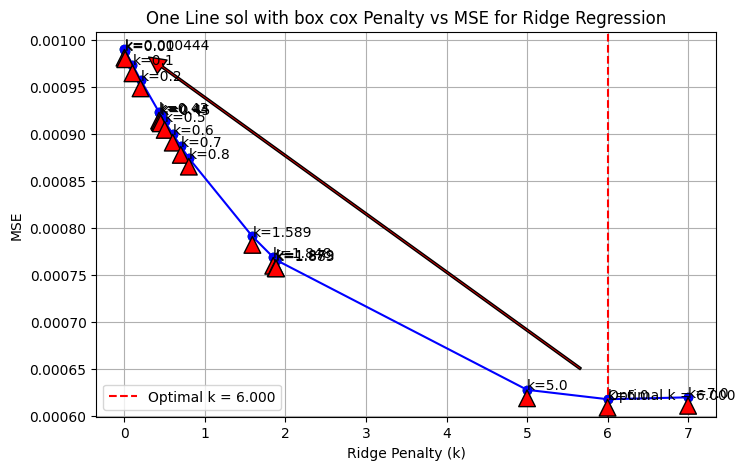

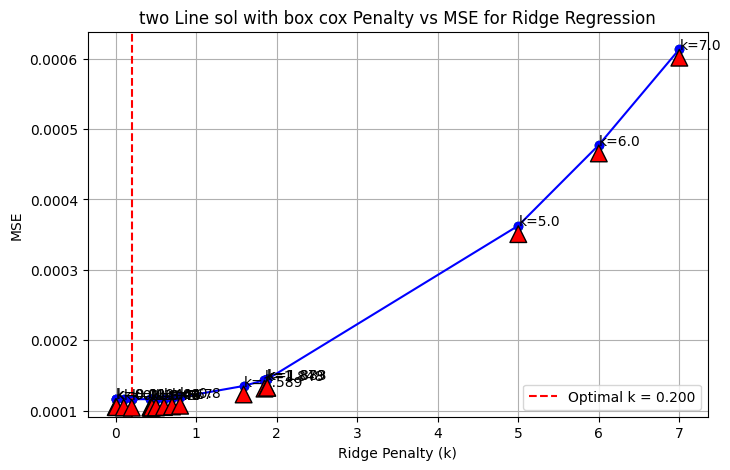

In [23]:
#ridge_penalty_param__ = optimum_k_one_lin_sol_bc  
mse_df  = ridge_mse(X_regressor = X_single_sol_bc, 
                   y_dependent_variable = y_single_sol_bc, 
                   k_list = optimum_k_concidered_all
                   #k_list = ridge_penalty_param__
                   )

plot_ridge_mse(mse_df,optimum_k_concidered_all,model_name = 'One Line sol with box cox')

#ridge_penalty_param__ = optimum_k_one_lin_sol_bc  
mse_df  = ridge_mse(X_regressor = X_two_sol_bc, 
                   y_dependent_variable = y_two_sol_bc, 
                   k_list = optimum_k_concidered_all
                   #k_list = ridge_penalty_param__
                   )

plot_ridge_mse(mse_df,optimum_k_concidered_all,model_name = 'two Line sol with box cox')

**Very small k (≈0.0004–0.01)**: behaves almost like ordinary least squares (OLS). If predictors are correlated, variance can be high, leading to unstable residuals. **Moderate k (≈0.1–0.45)**: often the sweet spot. Regularization stabilizes coefficients, reducing variance without adding too much bias. In your earlier plot, the minimum MSE was around k\approx 0.2. **Large k (≥5.0): heavy shrinkage**. Coefficients are forced close to zero, bias dominates, and MSE increases sharply.

Best region:

From your candidate list, the good plots are those around k=0.2 (and nearby values like 0.1, 0.43–0.45). These are the penalty values where residuals are well‑behaved and MSE is minimized.
🚩 Less effective regions
- Extremely small k (0.000444, 0.01) → risk of overfitting.
- Large k (5.0, 6.0, 7.0) → underfitting, high bias, poor residual distribution

The most informative and “good” plots for diagnostics are those around k=0.2. That’s where the balance between bias and variance is optimal, and the residuals vs leverage, histograms, and Q‑Q plots will look closest to ideal.

Since you’re evaluating Ridge penalties across a range of $k$ values, the one‑line solution is better for identifying the optimal $k$ (like the clear minimum around $k\approx 0.2$). It gives a straightforward diagnostic of where MSE is minimized.
The two‑line solution becomes valuable if you’re comparing two different transformations or model variants (for example, raw residuals vs Box‑Cox adjusted residuals). In that case, the second line helps you see whether the penalty that minimizes error is consistent across both formulations.

- Use one‑line plots when the goal is to find the optimal $k$ quickly and clearly.
- Use two‑line plots when you need to compare two modeling strategies side by side.


#### Plot $SS_{Res}$ vs $k$

In [24]:
def ridge_ss_ms(X_regressor: np.ndarray, y_dependent_variable: pd.DataFrame, k_list: list) -> pd.DataFrame:
    """
    Calculate Residual Sum of Squares (SS_res) and Residual Mean Square (MS_res)
    for ridge regression given X, y, and a list of ridge parameters k.
    
    Parameters:
    -----------
    X_regressor : np.ndarray
        Design matrix of predictors (n x p).
    y_dependent_variable : pd.DataFrame
        Response vector (n x 1).
    k_list : list
        List of ridge penalty values (k).
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with columns:
        - K (ridge parameter)
        - SSres (residual sum of squares)
        - MSres (residual mean square)
    """
    # Convert y to numpy array
    y = y_dependent_variable.values.flatten()
    
    # Precompute X'X and X'y
    XtX = X_regressor.T @ X_regressor
    Xty = X_regressor.T @ y
    
    n, p = X_regressor.shape
    
    results = []
    
    for k in k_list:
        # Ridge estimator: beta_R = (X'X + kI)^(-1) X'y
        beta_r = np.linalg.inv(XtX + k * np.eye(XtX.shape[0])) @ Xty
        
        # Residuals: y - X beta_R
        residuals = y - X_regressor @ beta_r
        
        # Residual sum of squares: r'r
        ss_res = residuals.T @ residuals
        
        # Residual mean square: SS_res / (n - p)
        ms_res = ss_res / (n - p)
        
        results.append([k, ss_res, ms_res])
    
    # Create DataFrame
    df_ss_ms = pd.DataFrame(results, columns=["K", "SSres", "MSres"])
    
    return df_ss_ms

def plot_ss_ms(df____: pd.DataFrame,models_name = ''):
    """
    Plot K vs SSres and MSres from the DataFrame using subplots (2 rows, 1 column).
    """
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot SSres on the first subplot
    axes[0].plot(df____["K"], df____["SSres"], marker="o", color="blue", label="SSres")
    axes[0].set_ylabel("SSres")
    axes[0].set_title(f"{models_name} Ridge Regression: SSres vs K")
    axes[0].legend()
    axes[0].grid(True)

    # Plot MSres on the second subplot
    axes[1].plot(df____["K"], df____["MSres"], marker="s", color="green", label="MSres")
    axes[1].set_xlabel("Ridge Parameter (K)")
    axes[1].set_ylabel("MSres")
    axes[1].set_title(f"{models_name} Ridge Regression: MSres vs K")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


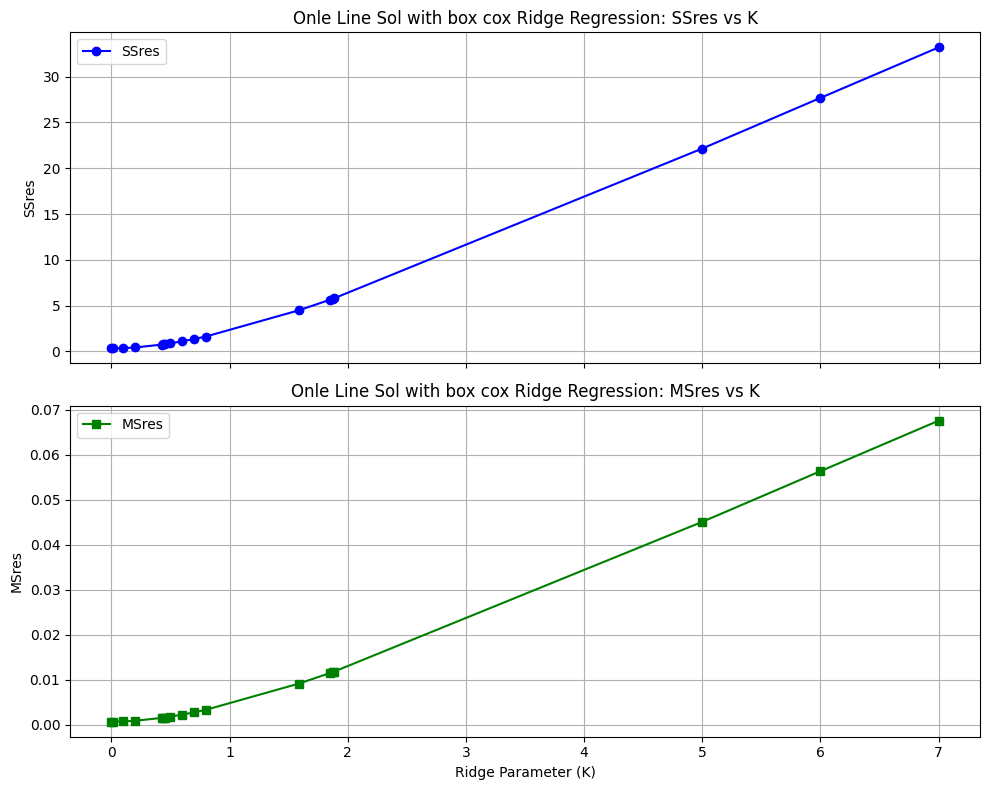

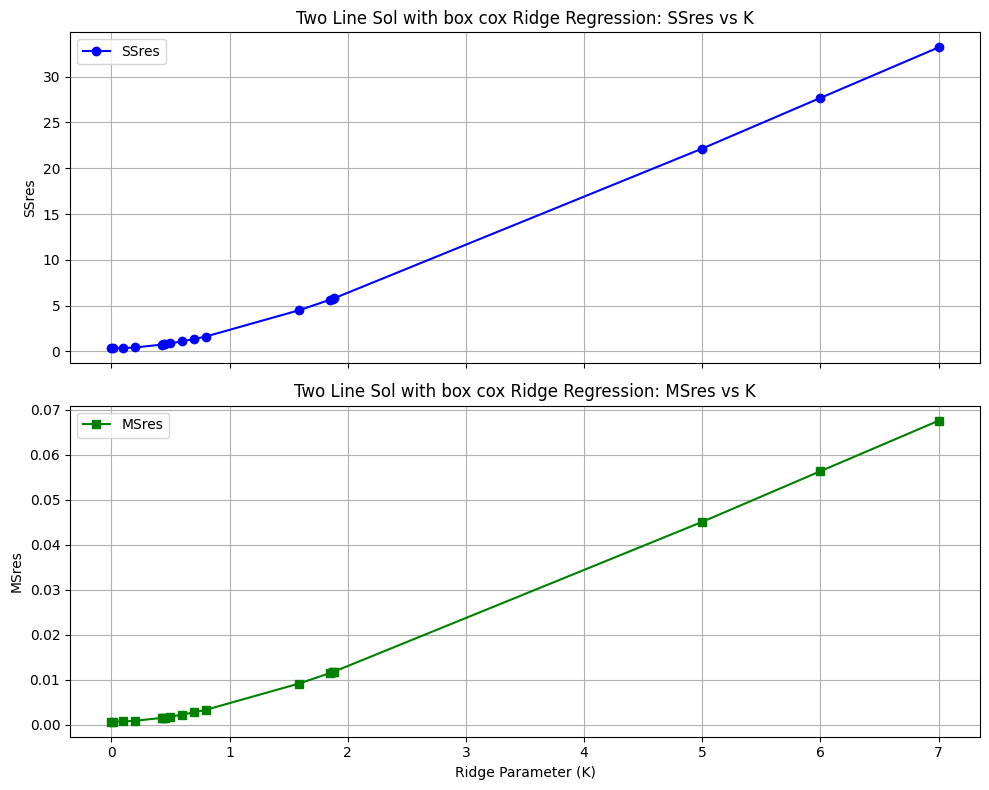

In [25]:
df_results_ss_ms = ridge_ss_ms(X_regressor = X_single_sol_bc, 
                         y_dependent_variable = y_single_sol_bc, 
                         k_list    = optimum_k_concidered_all)

plot_ss_ms(df____=df_results_ss_ms,models_name='Onle Line Sol with box cox')

df_results_ss_ms = ridge_ss_ms(X_regressor = X_single_sol_bc, 
                         y_dependent_variable = y_single_sol_bc, 
                         k_list    = optimum_k_concidered_all)

plot_ss_ms(df____=df_results_ss_ms,models_name='Two Line Sol with box cox')

**Choosing the Best K**
- SSres (Sum of Squared Residuals) and MSres (Mean Squared Residuals) both increase as K grows.
- In Ridge Regression, K (the penalty term) controls regularization:
- Small K → less penalty, closer to ordinary least squares, lower residuals but risk of overfitting.
- Large K → stronger penalty, coefficients shrink more, residuals increase, risk of underfitting.
- Since both SSres and MSres rise monotonically with K, the best K is at the lowest point of the curve (near the left side, small K).
That’s where residuals are minimized, meaning the model fits the data best while still applying some regularization.
👉 So, the optimal K is the smallest value before residuals start increasing noticeably — essentially the "elbow" point in the curve.

- One Line Solution with Box-Cox Ridge Regression
- Two Line Solution with Box-Cox Ridge Regression
- From the plots:

Both approaches show residuals increasing with K. If the Two Line Solution consistently has lower SSres/MSres than the One Line Solution at the same K, it means it fits better. If the curves overlap or the One Line Solution is lower, then that’s the better choice.

Box-Cox transformation stabilizes variance and makes residuals more normal. If the Two Line Solution achieves lower residuals, it suggests the extra flexibility (two-line model) captures the data structure better after transformation. If the One Line Solution is lower, then the simpler model is sufficient and avoids unnecessary complexity.

Best K: The smallest K value where SSres/MSres are minimized (near the left side of the plots). Compare the residual levels directly: If Two Line Solution has lower SSres/MSres → it’s better.- If One Line Solution has lower SSres/MSres → stick with the simpler model.


In [26]:
def ridge_rsquare(
    X_regressor: np.ndarray,
    y_dependent_variable: pd.DataFrame,
    k_list: list
) -> pd.DataFrame:
    """
    Calculate R² and Adjusted R² for ridge regression across given k_list.
    Returns a DataFrame with columns ["K", "RSqr", "AdjRsqr"].
    Also plots K vs R² and Adjusted R² in subplots (2 rows, 1 column).
    """
    y = y_dependent_variable.values.flatten()
    n, p = X_regressor.shape
    
    results = []
    
    # Total Sum of Squares (SST)
    SS_tot = np.dot(y, y) - (np.sum(y) ** 2) / n
    
    for k in k_list:
        # Ridge estimator: beta_hat = (X'X + kI)^(-1) X'y
        XtX = X_regressor.T @ X_regressor
        XtY = X_regressor.T @ y
        beta_hat = np.linalg.inv(XtX + k * np.eye(p)) @ XtY
        
        # Residuals and SSres
        y_hat = X_regressor @ beta_hat # y_hat Fitted Values
        residuals = y - y_hat
        SS_res = residuals.T @ residuals
        
        #RMSE
        rmse = mean_squared_error(y, y_hat)
        
        # R²
        R2 = 1 - SS_res / SS_tot
        
        # Adjusted R²
        AdjR2 = 1 - ((1 - R2) * (n - 1)) / (n - p - 1)
        
        results.append([k, R2, AdjR2, rmse])
    
    # Convert to DataFrame
    df_rsqr_results = pd.DataFrame(results, columns=["K", "RSqr", "AdjRsqr","rmse"])
    return df_rsqr_results

def plot_rsqr_adj_rsqr_vs_k(_df____,models_name = ''):    
    # Plotting
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
    
    # R² plot
    axes[0].plot(_df____["K"], _df____["RSqr"], marker="o", color="blue", label="R²")
    axes[0].set_ylabel("R²")
    axes[0].set_title(f"{models_name} R² vs Ridge Parameter (K)")
    axes[0].legend()
    axes[0].grid(True)
    
    # Adjusted R² plot
    axes[1].plot(_df____["K"], _df____["AdjRsqr"], marker="s", color="green", label="Adjusted R²")
    axes[1].set_xlabel("Ridge Parameter (K)")
    axes[1].set_ylabel("Adjusted R²")
    axes[1].set_title(f"{models_name} Adjusted R² vs Ridge Parameter (K)")
    axes[1].legend()
    axes[1].grid(True)
    
    # rms plot
    axes[2].plot(_df____["K"], _df____["rmse"], marker="s", color="red", label="rmse")
    axes[2].set_xlabel("Ridge Parameter (K)")
    axes[2].set_ylabel("rmse")
    axes[2].set_title(f"{models_name} rmse vs Ridge Parameter (K)")
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()    
    return 

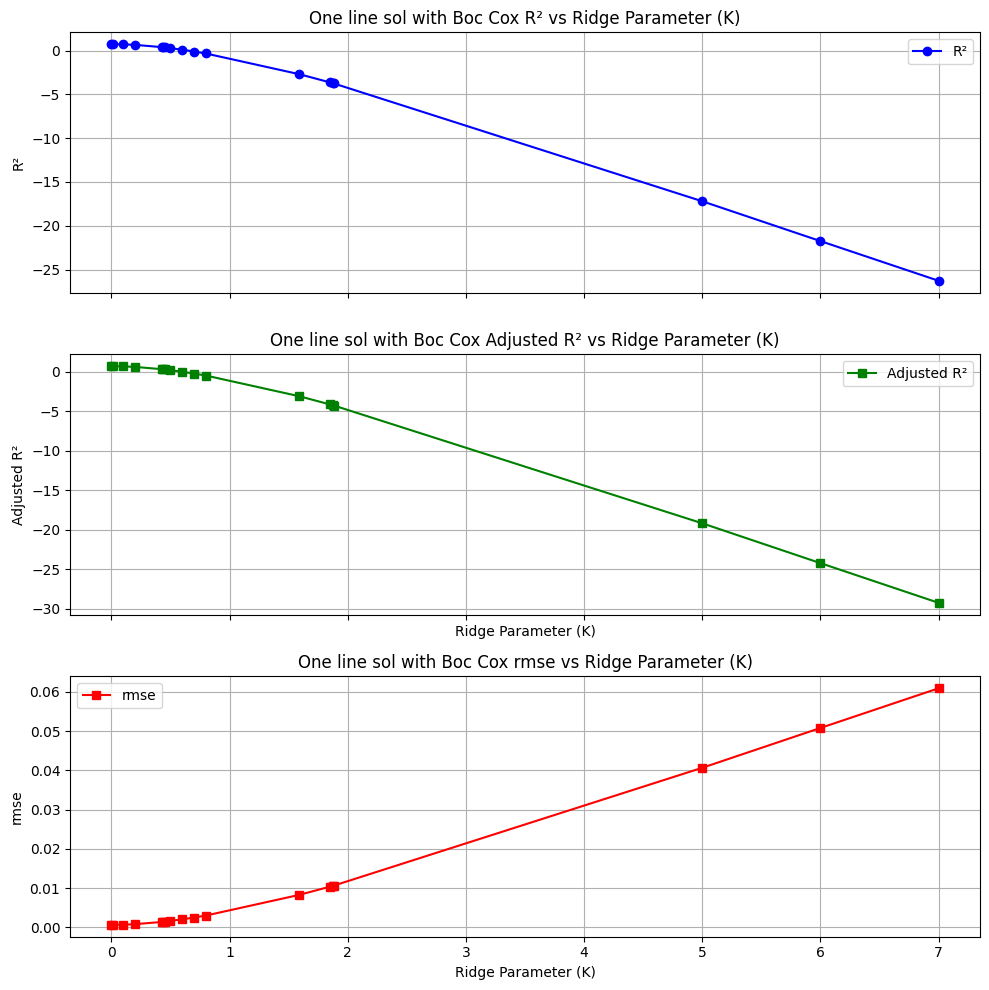

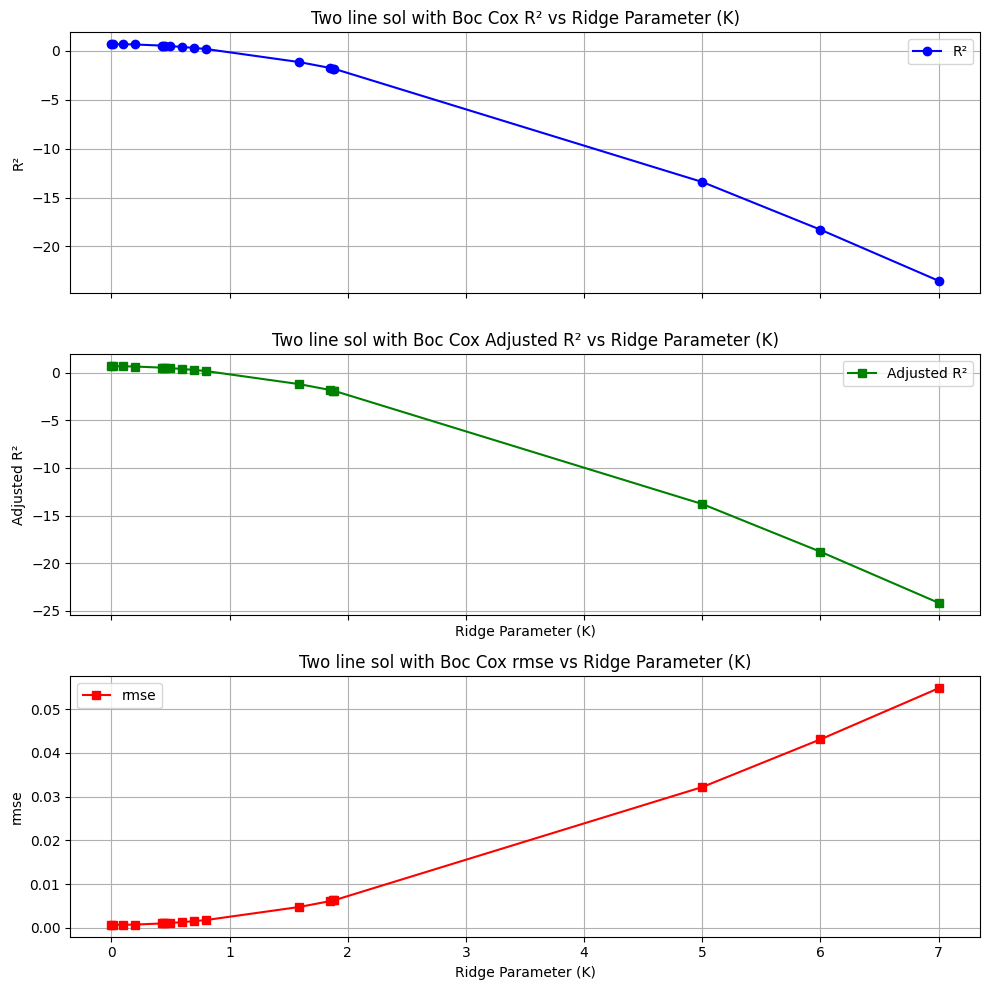

In [27]:
df_results_r_sqr = ridge_rsquare(X_regressor = X_single_sol_bc, 
                         y_dependent_variable = y_single_sol_bc, 
                         k_list    = optimum_k_concidered_all)
plot_rsqr_adj_rsqr_vs_k(_df____= df_results_r_sqr,models_name = 'One line sol with Boc Cox')

df_results_r_sqr = ridge_rsquare(X_regressor = X_two_sol_bc, 
                         y_dependent_variable = y_two_sol_bc, 
                         k_list    = optimum_k_concidered_all)
plot_rsqr_adj_rsqr_vs_k(_df____= df_results_r_sqr,models_name = 'Two line sol with Boc Cox')

Best $K$ Value
Adjusted $R^2$ measures how well the model explains variance while penalizing unnecessary complexity. In both one-line and two-line solutions:
- Adjusted $R^2$ decreases as $K$ increases.
- This is expected: stronger ridge penalty shrinks coefficients, reducing explanatory power.
- The best $K$ is therefore the smallest value of $K$ (near the left side of the plot), where Adjusted R^2 is maximized.
That’s the point where the model balances fit and regularization most effectively.
👉 In practice, you’d pick the lowest K before Adjusted R^2 starts dropping sharply — the “elbow” point.

- One Line Solution with Box-Cox Ridge Regression
- Two Line Solution with Box-Cox Ridge Regression
- **Observation from plots**: If the Two Line Solution consistently shows higher Adjusted R^2 than the One Line Solution at the same K, it means it explains more variance and is the better fit. If the One Line Solution has higher Adjusted R^2, then the simpler model is preferable (less complexity, still strong explanatory power). Box-Cox transformation helps stabilize variance and improve normality of residuals.
Between the two, whichever approach yields **higher Adjusted R^2**andlowerRMSE(fromyourotherplots)isthebetterchoic

- **Best $K$**: The smallest K value where Adjusted R^2 is maximized (near the left side of the curve).
- Better Approach:
- If Two Line Solution has higher Adjusted R^2 → it’s better.
- If One Line Solution has higher Adjusted R^2 → stick with the simpler model.




#### Residulals Analysis:

Residuals analysis was performed to identify optimum values using multiple ridge regression criteria: ***GCV_ridge (k), PRESS_ridge (k), Mallows Ck_Vk (k), and Hoerl–Kennard (k)***.

For further modeling, we considered two approaches:
- A two-line solution model without interaction terms.
- A single-line solution model that incorporates interaction terms and operates in higher dimensions.

The optimum k values derived from these Box-Cox transformed models guided the selection of the most appropriate ridge parameters for subsequent analysis.

Note: Little modification in Optimum k value:

optimum_k_concidered_all = [0.000444, 0.01, 0.1, 0.45, 0.8, 1.589, 1.848, 1.879, 1.883, 5.0, 6.0, 7.0]

$\mathrm{Mean}=\frac{1.589+1.848+1.879+1.883}{4}$

$\mathrm{Mean}=\frac{7.199}{4}=1.79975$

$\mathrm{Mean}=\frac{5.0+6.0+7.0}{3}$

$\mathrm{Mean}=\frac{18.0}{3}=6.0$

optimum_k_concidered_all = [0.000444, 0.01, 0.1, 0.45, 0.8, 1.79975, 6.0]

#### Plot  fitted values Vs residuals

In [28]:
modified_optimum_k_concidered_all = [0.000444, 0.01, 0.1, 0.45, 0.8, 1.79975, 6.0,7.0]

In [29]:
def ridge_residuals_fitted(
    X_regressor: np.ndarray,
    y_dependent_variable: pd.DataFrame,
    k_values: list,
    model_name: str = ""
) -> dict:
    """
    Calculate fitted values and residuals using ridge regression
    for a list of k_values. Plot fitted vs residuals for each k.
    
    Parameters
    ----------
    X_regressor : np.ndarray
        Design matrix (regressors).
    y_dependent_variable : pd.DataFrame
        Dependent variable (target).
    k_values : list of float
        Ridge penalty values.
    model_name : str
        Name of the model (used in plot title).
    
    Returns
    -------
    results_dict : dict
        Dictionary of DataFrames keyed by k_value, each containing
        fitted values and residuals.
    """
    y = y_dependent_variable.values.flatten()
    n, p = X_regressor.shape
    results_dict = {}

    fig, axes = plt.subplots(len(k_values), 1, figsize=(8, 4 * len(k_values)))
    if len(k_values) == 1:
        axes = [axes]  # ensure iterable

    for i, k in enumerate(k_values):
        # Ridge estimator: beta_hat = (X'X + kI)^(-1) X'y
        XtX = X_regressor.T @ X_regressor
        XtY = X_regressor.T @ y
        beta_hat = np.linalg.inv(XtX + k * np.eye(p)) @ XtY

        fitted_vals = X_regressor @ beta_hat
        residuals = y - fitted_vals

        # Store results
        df_results = pd.DataFrame({
            f"{k}_fitted": fitted_vals,
            f"{k}_residuals": residuals
        })
        results_dict[k] = df_results

        # Plot fitted vs residuals
        #axes[i].scatter(fitted_vals, residuals, alpha=0.7, color="blue")
        sns.residplot(
        x=fitted_vals,
        y=residuals,
        lowess=True,
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red", "lw": 2, "alpha": 0.5},
        ax=axes[i]
        )
        # annotate top 3 absolute residuals
        residual_abs = np.abs(residuals)
        abs_resid = np.argsort(residual_abs)[::-1]  # sort descending
        abs_resid_top_3 = abs_resid[:3]
    
        #for i in abs_resid_top_3:
        #    axes[i].annotate(f'{i}', xy=(fitted_vals[i], residuals[i]), color="C3")
        axes[i].axhline(0, color="black", linestyle="--")
        axes[i].set_xlabel("Fitted Values")
        axes[i].set_ylabel("Residuals")
        axes[i].set_title(f"{model_name} | k = {k}")

    plt.tight_layout()
    plt.show()
    return results_dict

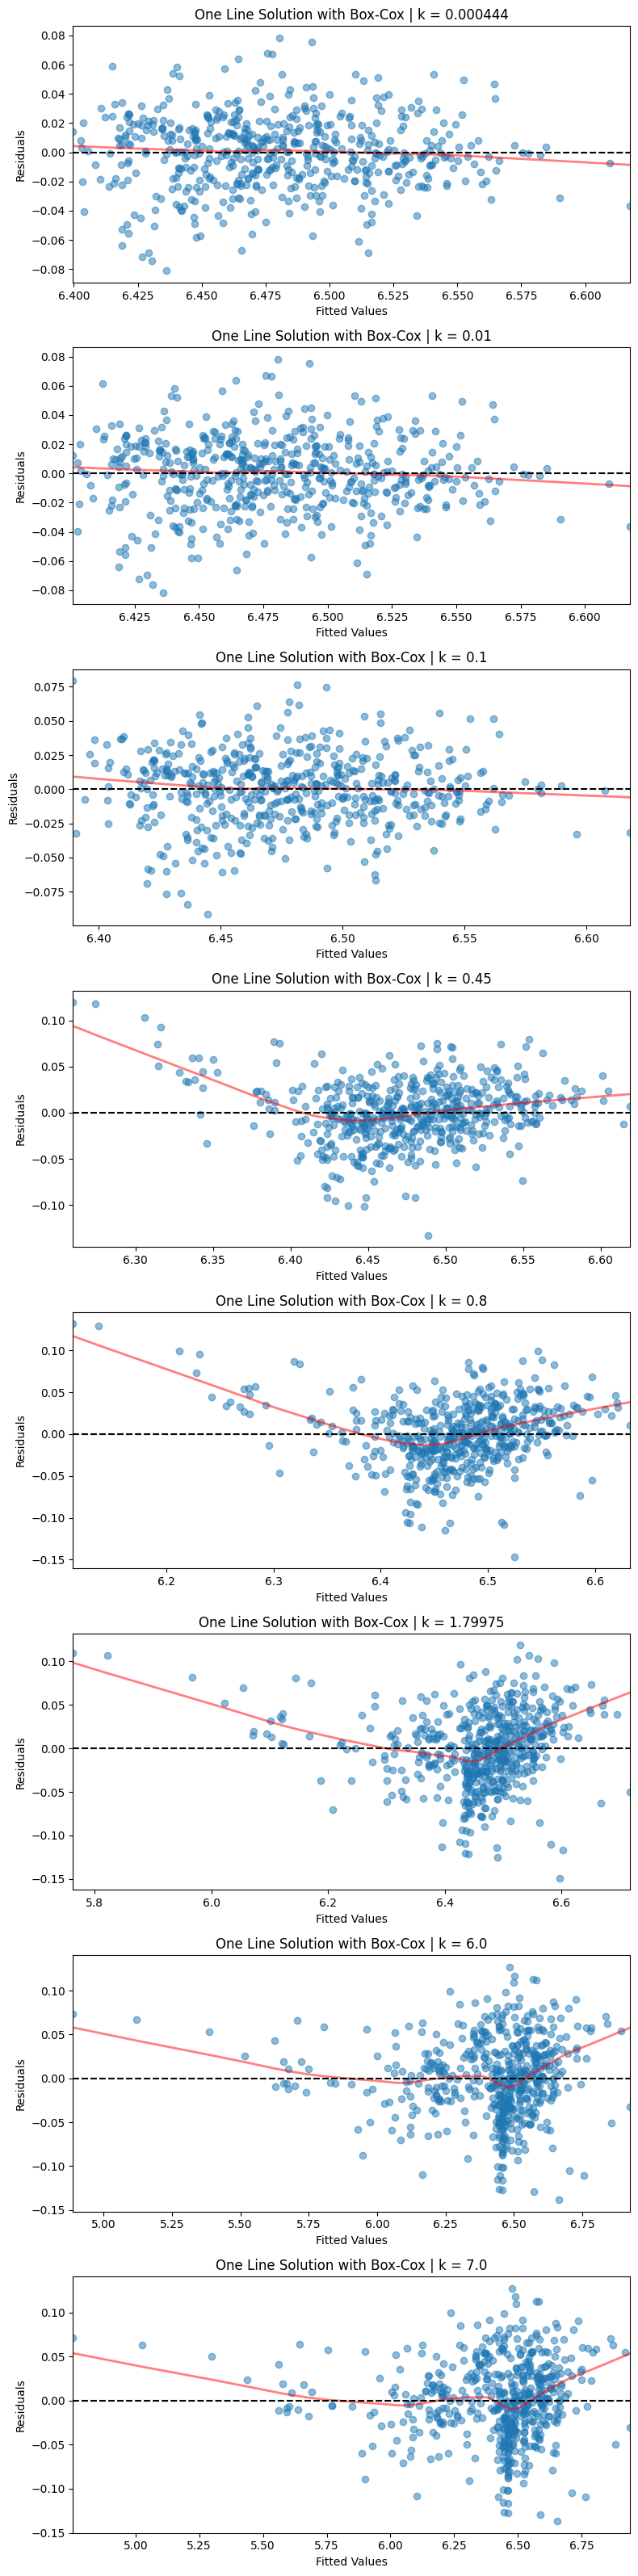

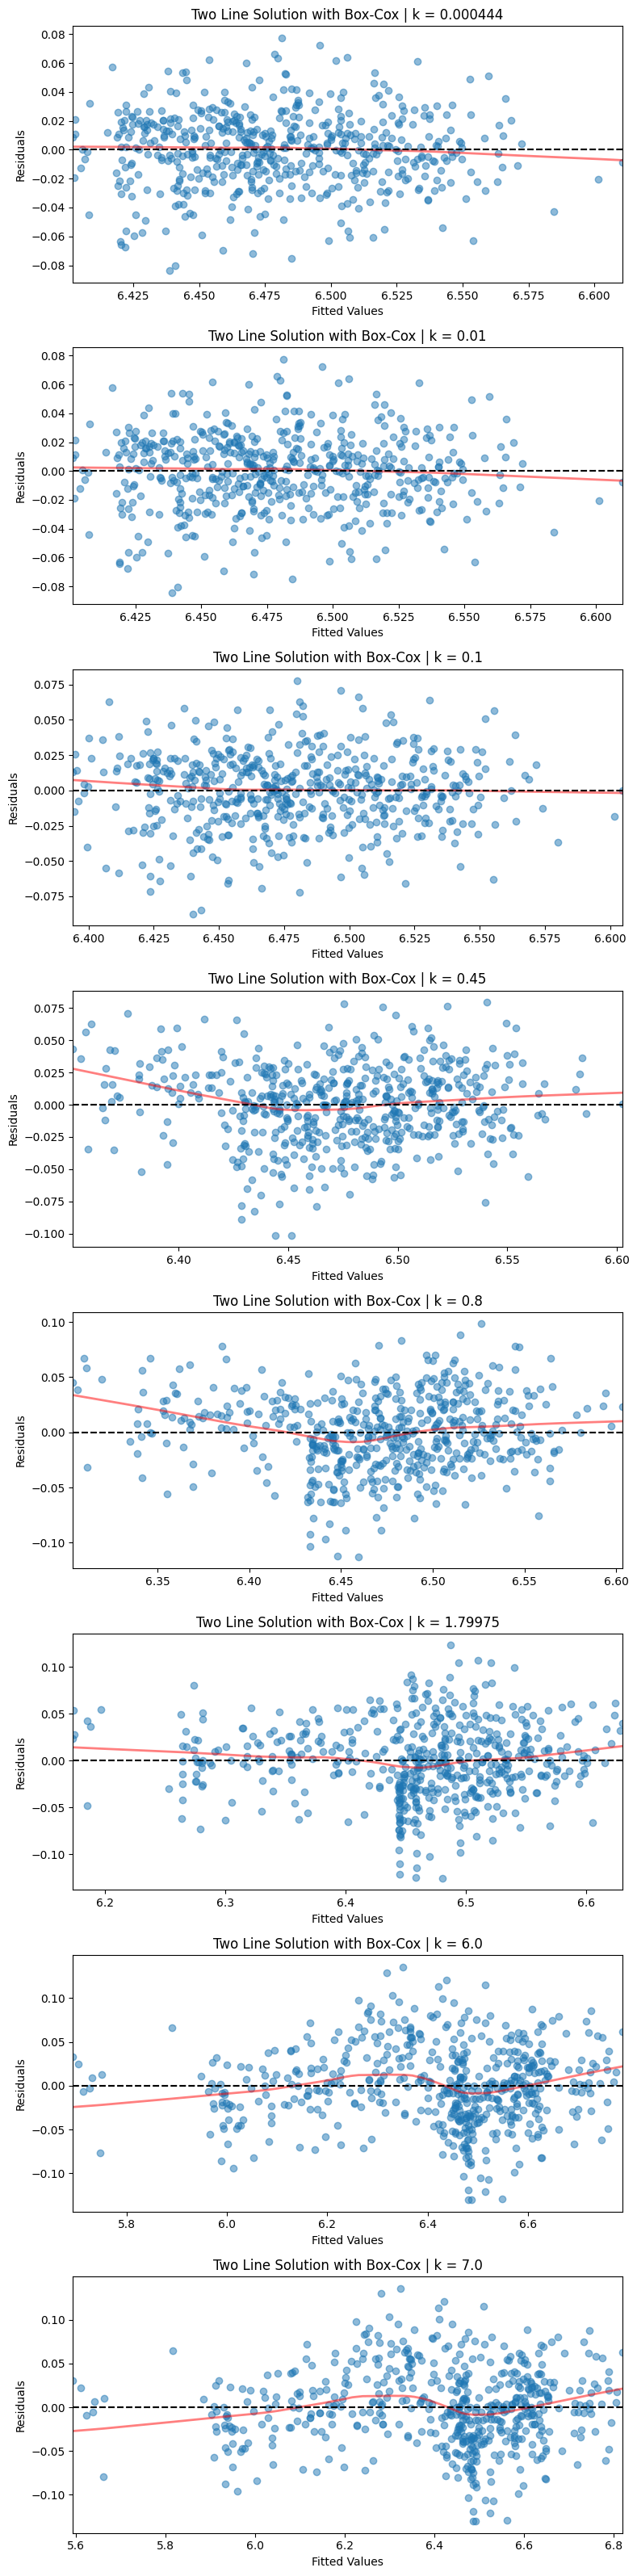

In [30]:
results = ridge_residuals_fitted(
    X_regressor=X_single_sol_bc,
    y_dependent_variable=y_single_sol_bc,
    k_values = modified_optimum_k_concidered_all,
    model_name="One Line Solution with Box-Cox"
)

results = ridge_residuals_fitted(
    X_regressor=X_two_sol_bc,
    y_dependent_variable=y_two_sol_bc,
    k_values = modified_optimum_k_concidered_all,
    model_name="Two Line Solution with Box-Cox"
)


#### Residuals vs Predictor Plot:

In [31]:
def ridge_wrapper(X_regressor: pd.DataFrame, y_var: pd.Series, k: float):
    """
    Ridge regression wrapper function.

    Parameters
    ----------
    X_regressor : pd.DataFrame
        Predictor DataFrame (n x p).
    y_var : pd.Series
        Dependent variable (n,).
    k : float
        Ridge penalty parameter.

    Returns
    -------
    pd.DataFrame
        DataFrame containing fitted values, residuals, and k.
    """
    # Convert to numpy arrays for matrix operations
    X = X_regressor.values
    y = y_var.values.flatten()
    n, p = X.shape

    # Ridge estimator: beta_hat = (X'X + kI)^(-1) X'y
    XtX = X.T @ X
    XtY = X.T @ y
    beta_hat = np.linalg.inv(XtX + k * np.eye(p)) @ XtY

    # Fitted values and residuals
    fitted_vals = X @ beta_hat
    residuals = y - fitted_vals
    return fitted_vals,residuals,k

def plot_residuals_vs_predictors_subplots(
    dfX: pd.DataFrame,
    residuals: pd.Series,
    rows: int = 2,
    cols: int = 2,
    predictor_names = [],
    model_title: str = "Residuals vs Predictors"
):
    """
    Plot residuals vs each predictor using matplotlib subplots.

    Parameters
    ----------
    dfX : pd.DataFrame
        Predictor DataFrame.
    residuals : pd.Series
        Residuals from regression (y - y_hat).
    rows : int
        Number of subplot rows.
    cols : int
        Number of subplot columns.
    model_title : str
        Title for the entire figure.
    """
    #predictor_names = list(dfX.columns)
    n_predictors = len(predictor_names)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()
    residuals = residuals[~np.isnan(residuals)]
    residuals = pd.Series(residuals, index=dfX.index)
    for i, col in enumerate(predictor_names):
        #axes[i].scatter(dfX[col], residuals, alpha=0.6, color="blue")
        sns.regplot(
            x=dfX[col],
            y=residuals,
            lowess=True,
            scatter=True,   # keep scatter points
            line_kws={"color": "black", "lw": 2, "alpha": 0.7},
            ax=axes[i]
        )
        axes[i].axhline(0, color="red", linestyle="--")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Residuals")
        axes[i].set_title(f"Residuals vs {col}")

    # Hide unused subplots if predictors < rows*cols
    for j in range(i+1, rows*cols):
        axes[j].axis("off")

    fig.suptitle(model_title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1,1.0])
    plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


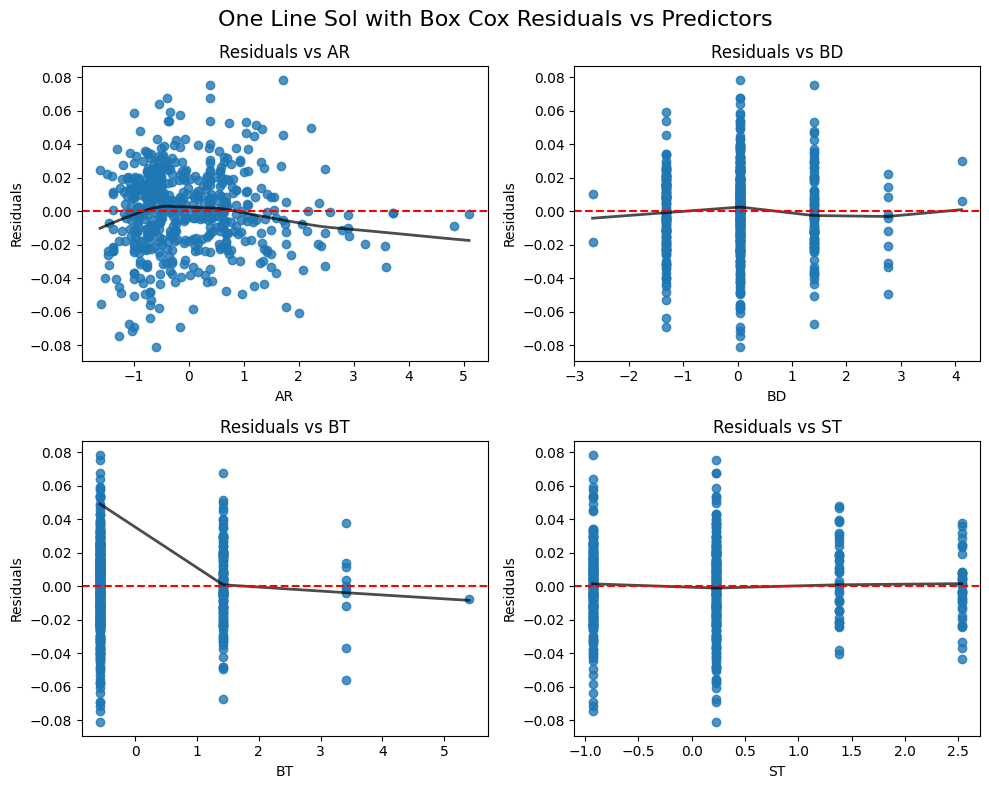

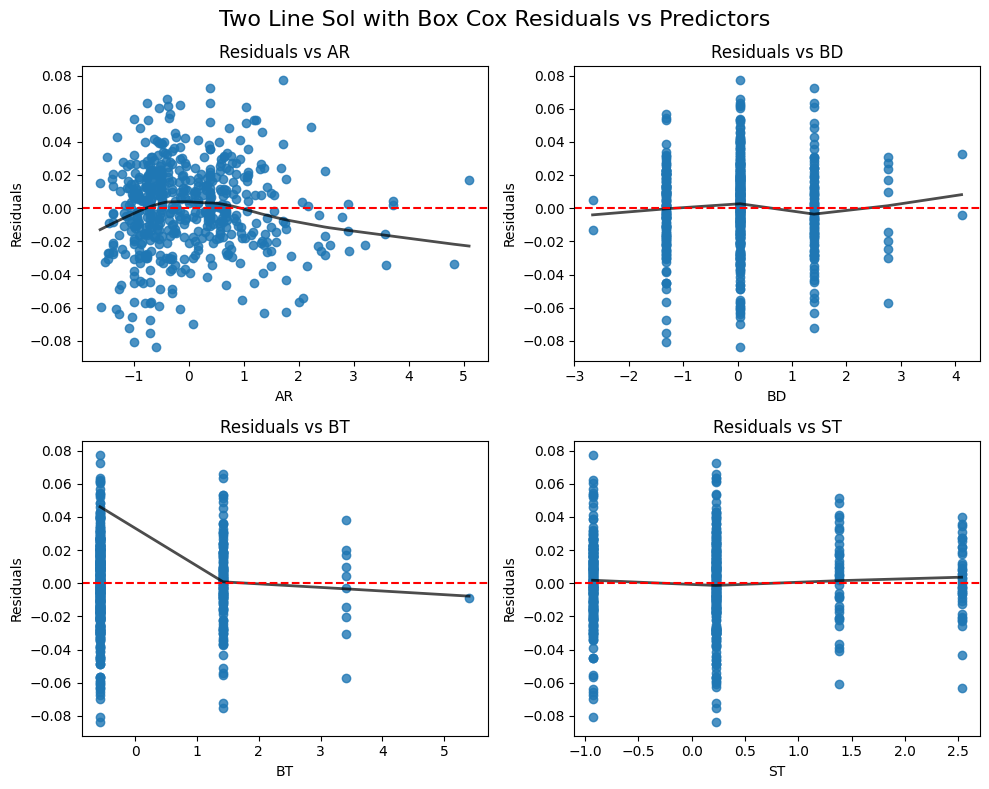

In [32]:
fitted_vals_,residuals_,k_ = ridge_wrapper(X_regressor = X_single_sol_bc, y_var = y_single_sol_bc, 
              k = modified_optimum_k_concidered_all[0])
plot_residuals_vs_predictors_subplots(
    dfX = X_single_sol_bc,
    residuals = residuals_,
    rows = 2,
    cols = 2,
    predictor_names = ['AR','BD','BT','ST'],
    model_title = "One Line Sol with Box Cox Residuals vs Predictors"
)

fitted_vals_,residuals_,k_ = ridge_wrapper(X_regressor = X_two_sol_bc, y_var = y_two_sol_bc, 
              k = modified_optimum_k_concidered_all[0])
plot_residuals_vs_predictors_subplots(
    dfX = X_two_sol_bc,
    residuals = residuals_,
    rows = 2,
    cols = 2,
    predictor_names = ['AR','BD','BT','ST'],
    model_title = "Two Line Sol with Box Cox Residuals vs Predictors"
)

#### Ridge regressions residulas analysis with hist plot

In [33]:
def plot_residuals_hist(residuals_df: pd.DataFrame, bins=30, model_name: str = "Regression Model"):
    cols = residuals_df.columns
    n_plots = len(cols)

    fig, axes = plt.subplots(4, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, col in enumerate(cols[:8]):  # limit to 2x2 grid
        residuals = residuals_df[col].dropna()

        skewness_val = skew(residuals, nan_policy="omit")
        kurtosis_val = kurtosis(residuals, nan_policy="omit")

        sns.histplot(residuals, bins=bins, kde=True, color="blue", alpha=0.6, ax=axes[i])
        axes[i].axvline(x=np.mean(residuals), color="red", linestyle="--", label="Mean Reference")
        axes[i].set_xlabel("Residuals")
        axes[i].set_ylabel("Frequency")
        axes[i].set_title(f"{model_name} | k={col}\nSkew={skewness_val:.2f}, Kurt={kurtosis_val:.2f}")
        axes[i].legend()
        axes[i].grid(True)

    # Hide unused subplots if fewer than 4 residual sets
    for j in range(i+1, 4):
        axes[j].axis("off")
    fig.suptitle(f"Residuals Histograms ({model_name})", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 1.0])
    plt.show()

def ridge_residuals_wrapper_(X_regressor: pd.DataFrame, y_var: pd.Series, k_list: list):    
    # Convert to numpy arrays for matrix operations
    X = X_regressor.values
    y = y_var.values.flatten()
    n, p = X.shape
    residuals_df = pd.DataFrame(index=X_regressor.index)
    for k in k_list:
        # Ridge estimator: beta_hat = (X'X + kI)^(-1) X'y
        XtX = X.T @ X
        XtY = X.T @ y
        beta_hat = np.linalg.inv(XtX + k * np.eye(p)) @ XtY

        # Fitted values and residuals
        fitted_vals = X @ beta_hat
        residuals = y - fitted_vals

        # Store residuals in DataFrame, column name = k value
        residuals_df[f'{k}'] = residuals
    return residuals_df

from sklearn.metrics import r2_score
def ridge_residuals_wrapper(X_regressor: pd.DataFrame, y_var: pd.Series, k_list: list):
    # Convert to numpy arrays for matrix operations
    X = X_regressor.values
    y = y_var.values.flatten()
    n, p = X.shape
    
    residuals_df = pd.DataFrame(index=X_regressor.index)
    accuracy_records = []  # to store (k, R², MSE)
    
    for k in k_list:
        # Ridge estimator: beta_hat = (X'X + kI)^(-1) X'y
        XtX = X.T @ X
        XtY = X.T @ y
        beta_hat = np.linalg.inv(XtX + k * np.eye(p)) @ XtY

        # Fitted values and residuals
        fitted_vals = X @ beta_hat
        residuals = y - fitted_vals

        # Store residuals in DataFrame, column name = k value
        residuals_df[f'{k}'] = residuals

        # Compute accuracy metrics
        r2 = r2_score(y, fitted_vals)
        mse = mean_squared_error(y, fitted_vals)
        
        # Append results
        accuracy_records.append((k, r2, mse))
    
    # Convert accuracy records into DataFrame
    df_accuracy = pd.DataFrame(accuracy_records, columns=['k', 'R2_score', 'MSE'])
    
    return residuals_df, df_accuracy

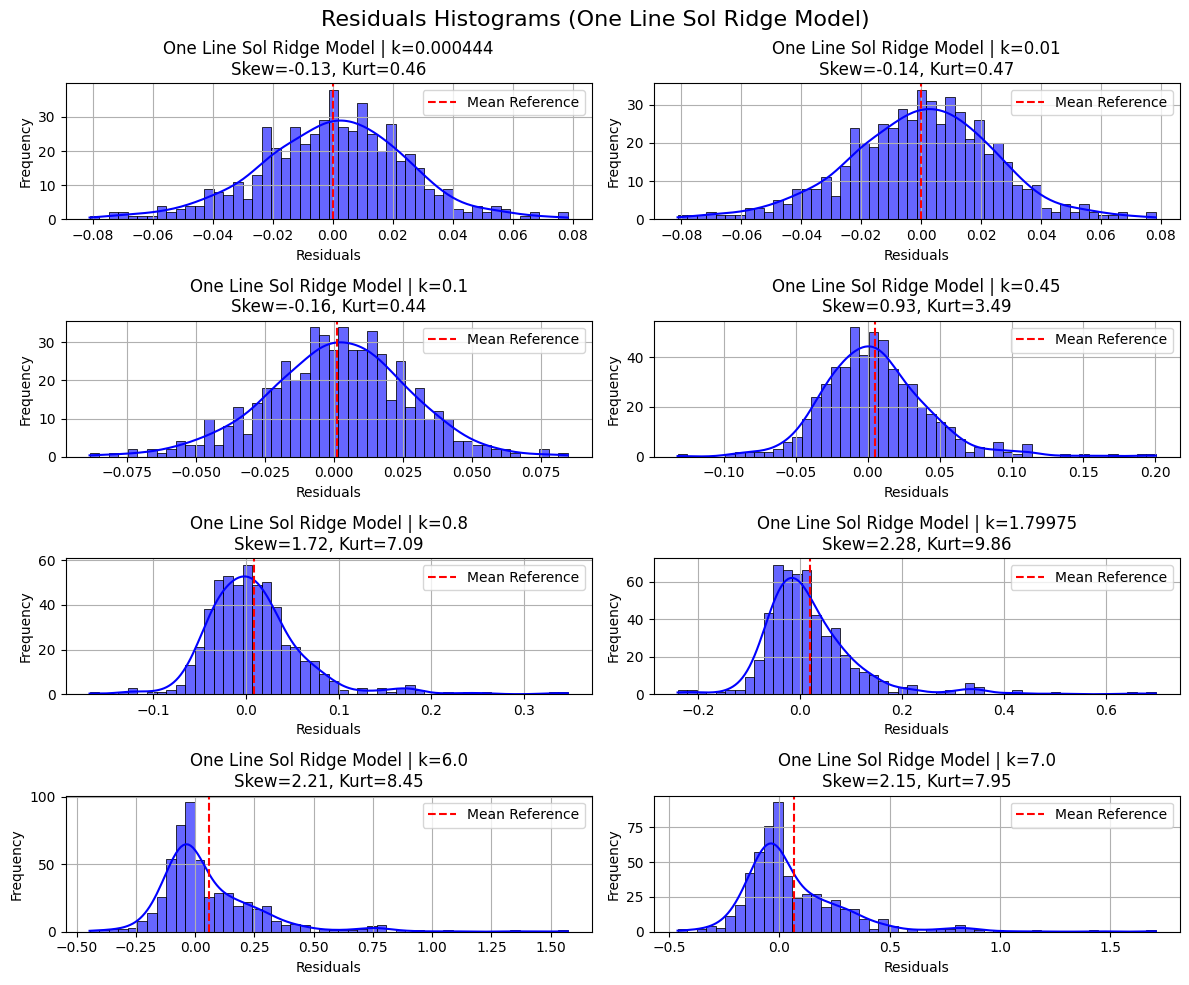

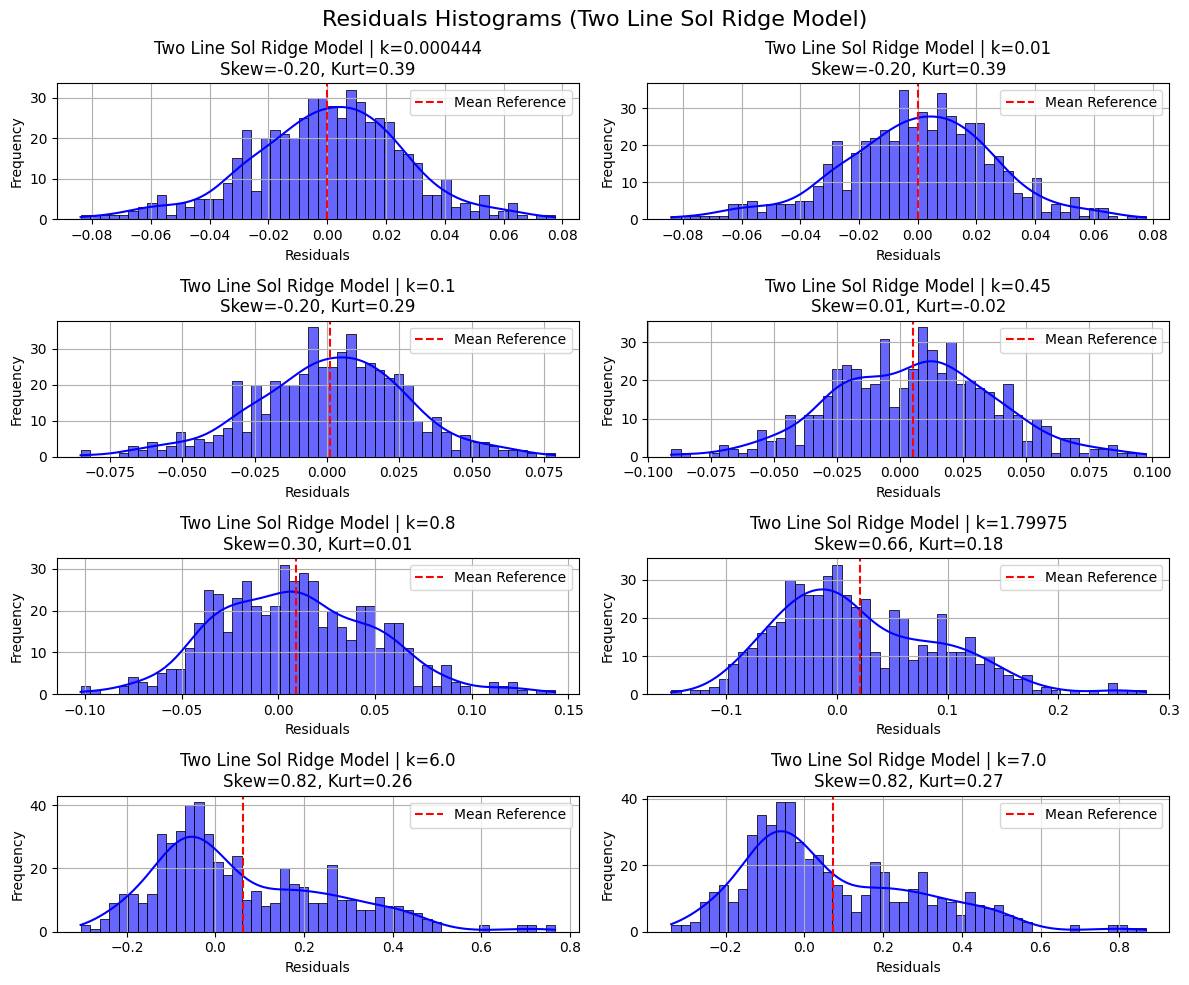

In [34]:
df_res_,_  = ridge_residuals_wrapper(X_regressor = X_single_sol_bc, 
                                   y_var = y_single_sol_bc, 
                                   k_list = modified_optimum_k_concidered_all
                                   )

plot_residuals_hist(residuals_df = df_res_, 
                    bins=50, 
                    model_name = "One Line Sol Ridge Model"
                    )

df_res_,_  = ridge_residuals_wrapper(X_regressor = X_two_sol_bc, 
                                   y_var = y_two_sol_bc, 
                                   k_list = modified_optimum_k_concidered_all
                                   )

plot_residuals_hist(residuals_df = df_res_, 
                    bins=50, 
                    model_name = "Two Line Sol Ridge Model"
                    )

In [35]:
def plot_residuals_qq(residuals_df: pd.DataFrame, lines='45', model_name: str = "Ridge Regression Model"):

    cols = residuals_df.columns
    n_plots = len(cols)

    fig, axes = plt.subplots(4, 2, figsize=(14, 18))
    axes = axes.flatten()

    for i, col in enumerate(cols[:8]):  # limit to 4x2 grid
        residuals = residuals_df[col].dropna()
        sm.qqplot(residuals, line=lines, fit=True, ax=axes[i])
        axes[i].set_title(f"Q-Q Plot ({model_name}) | k={col}")
        axes[i].grid(True)

    # Hide unused subplots if fewer than 8 residual sets
    for j in range(i+1, 8):
        axes[j].axis("off")

    fig.suptitle(f"Q-Q Plots of Residuals ({model_name})", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

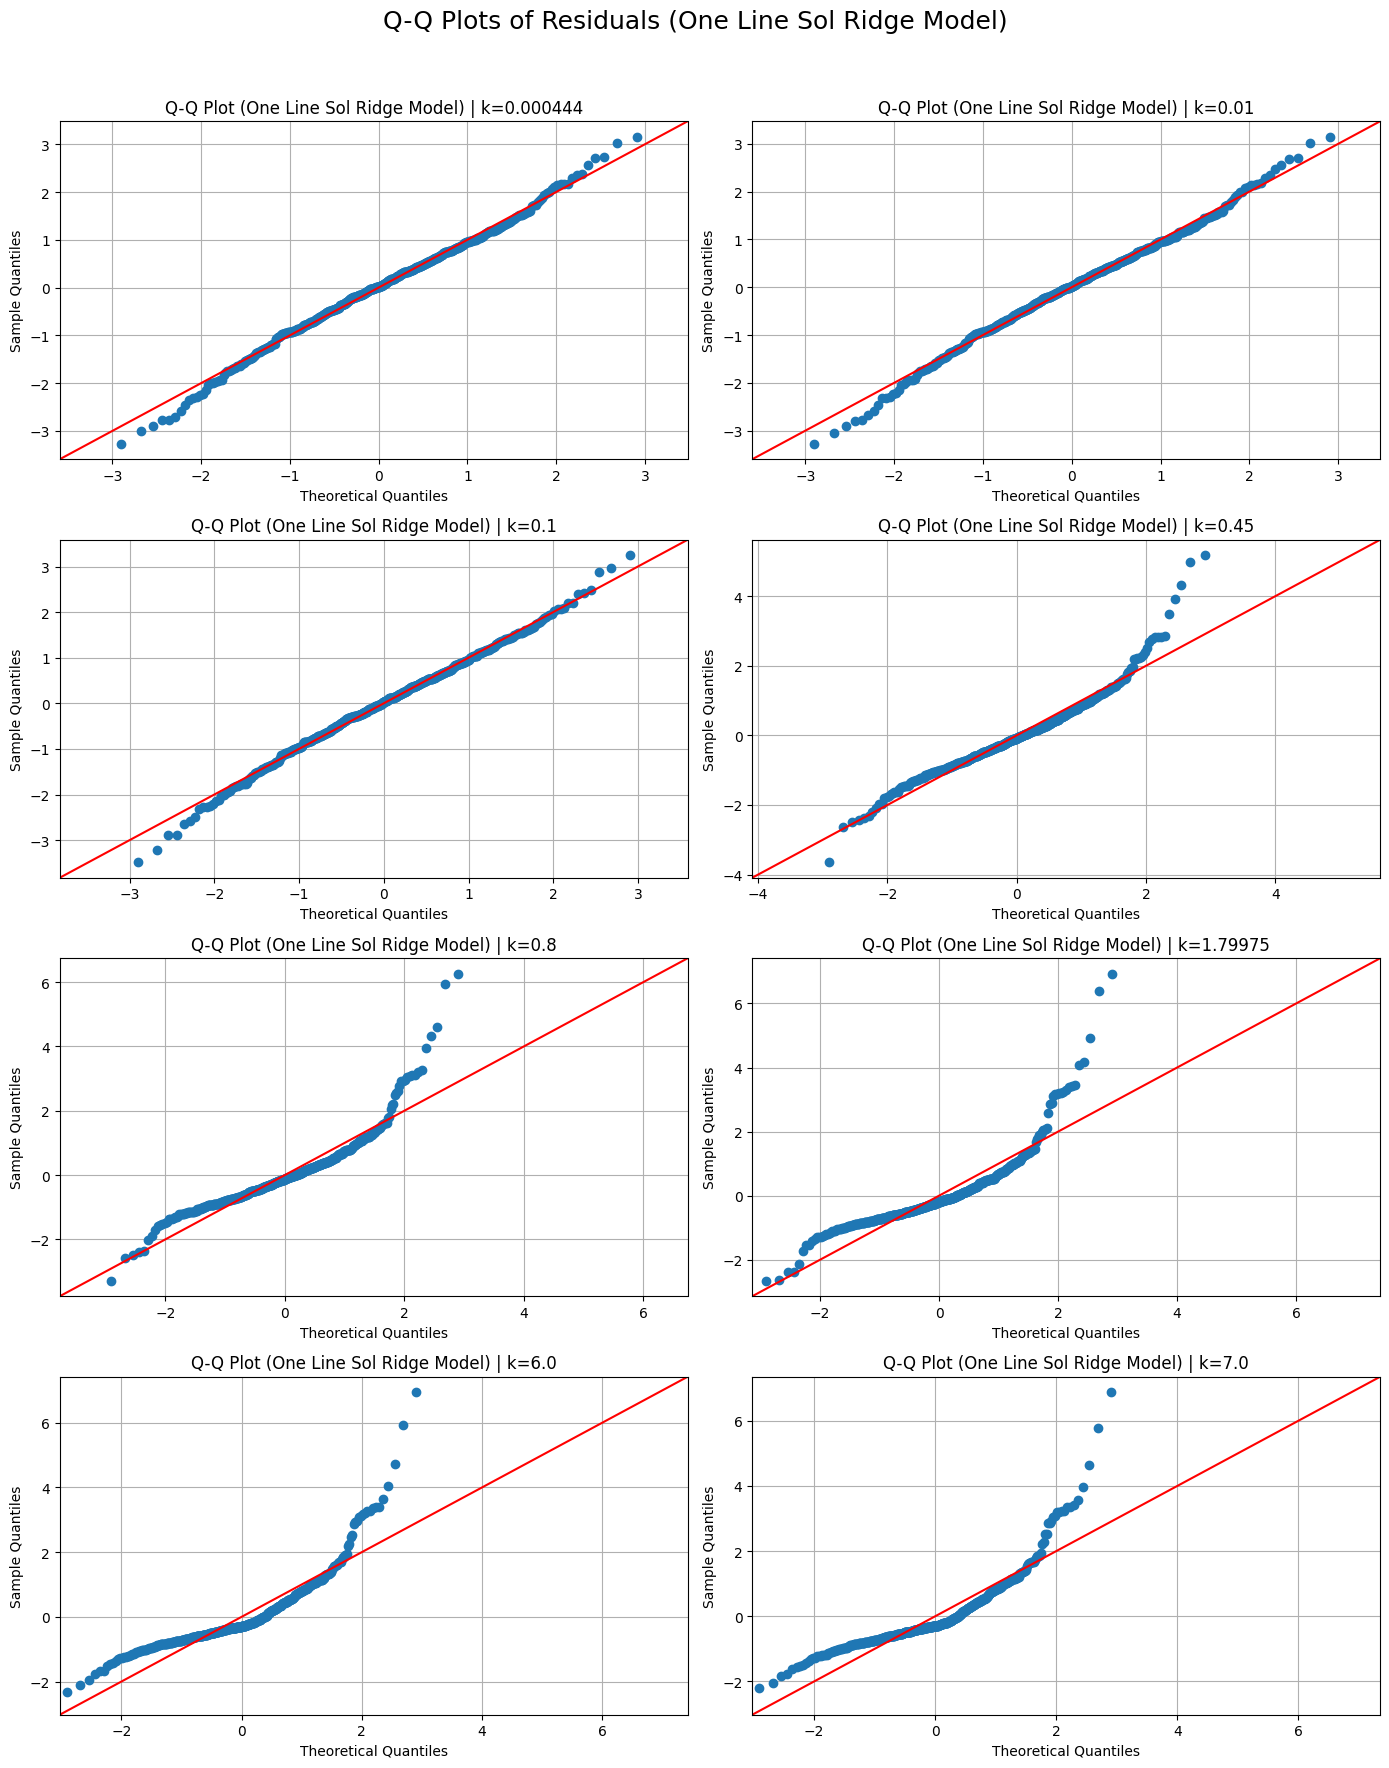

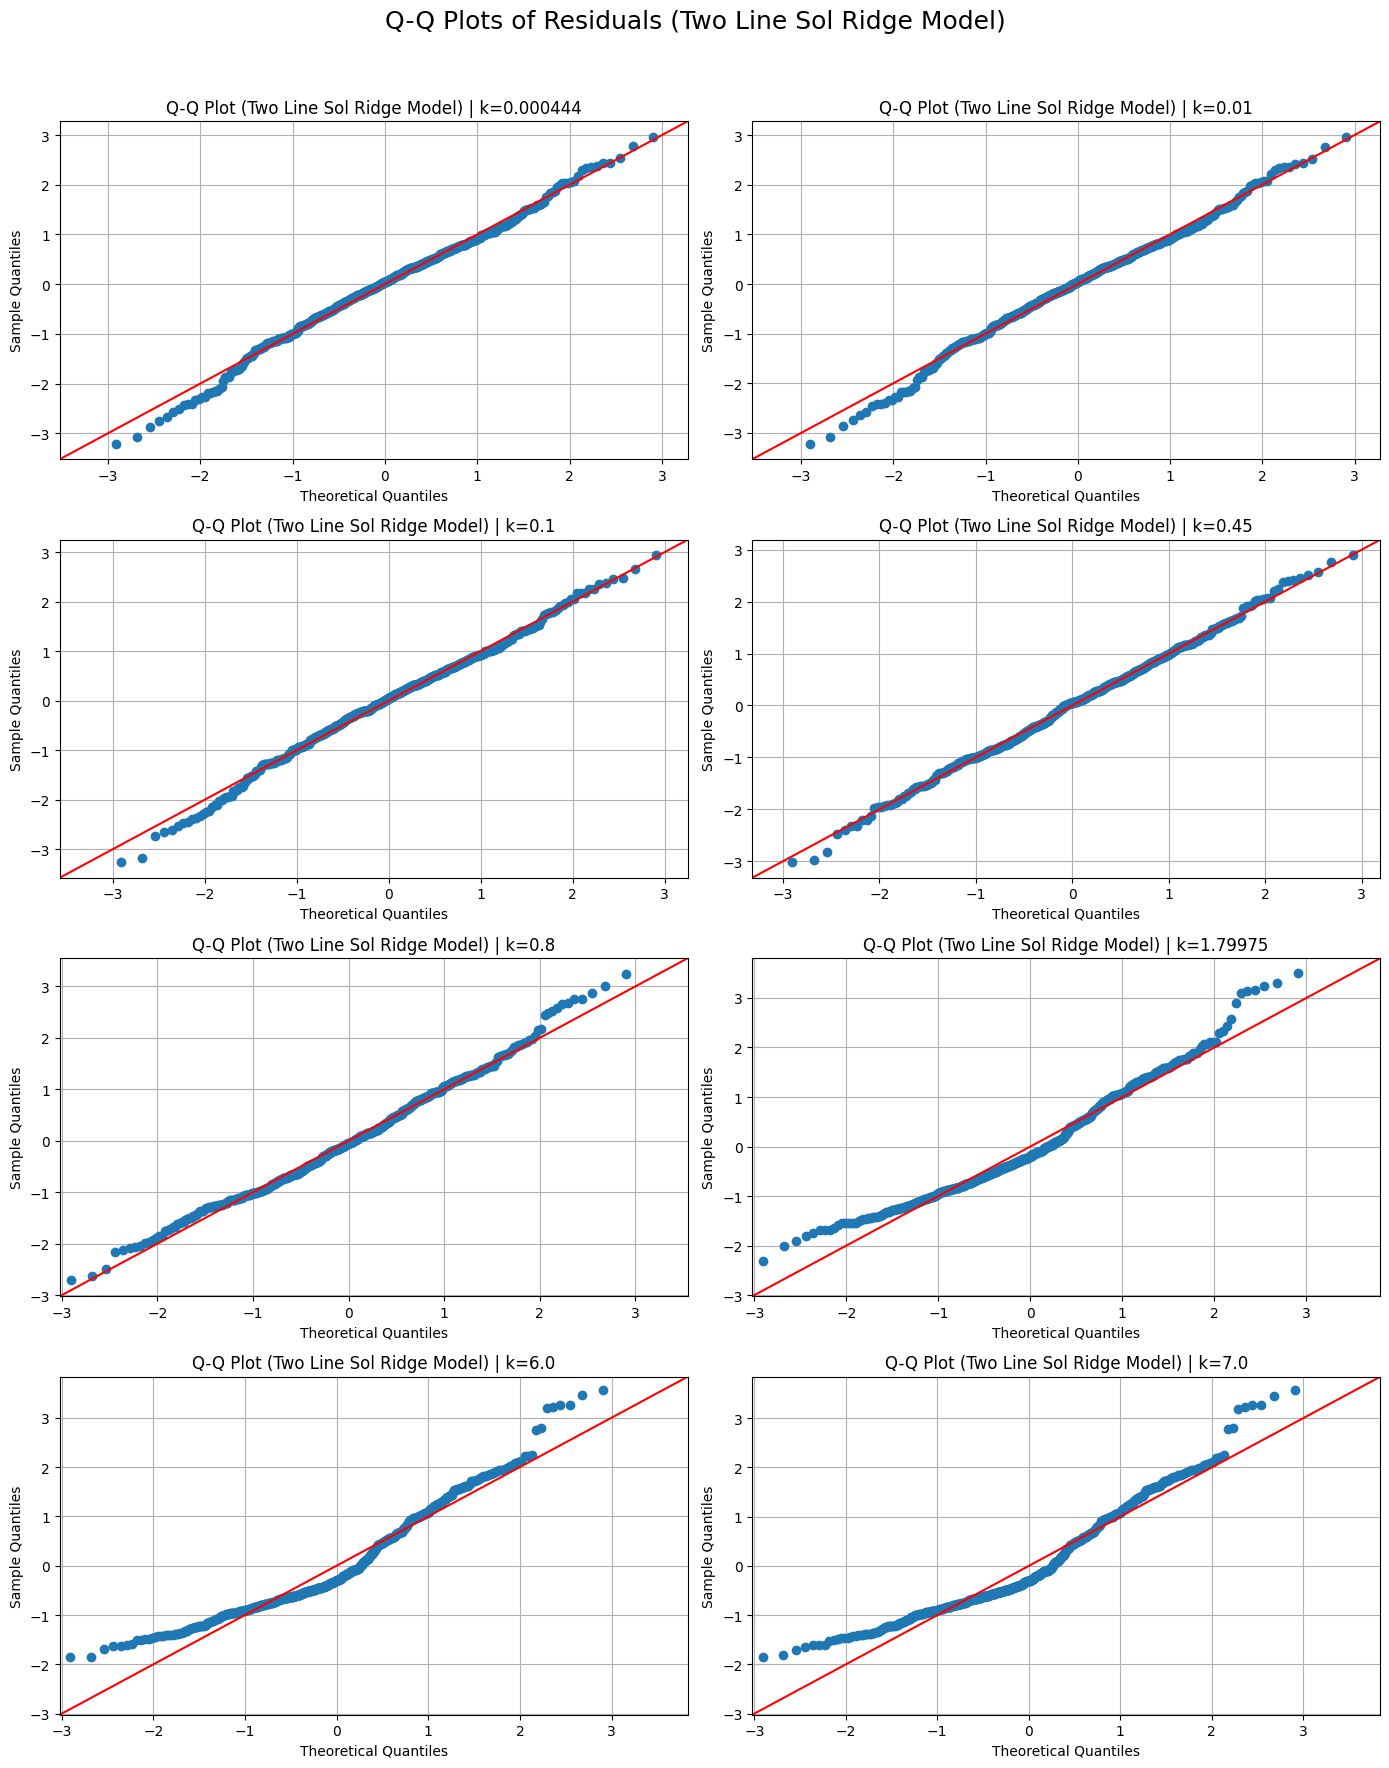

In [36]:
df_res_,_  = ridge_residuals_wrapper(X_regressor = X_single_sol_bc, 
                                   y_var = y_single_sol_bc, 
                                   k_list = modified_optimum_k_concidered_all
                                   )
plot_residuals_qq(residuals_df = df_res_, 
                  lines='45', 
                  model_name = "One Line Sol Ridge Model")

df_res_,_  = ridge_residuals_wrapper(X_regressor = X_two_sol_bc, 
                                   y_var = y_two_sol_bc, 
                                   k_list = modified_optimum_k_concidered_all
                                   )
plot_residuals_qq(residuals_df = df_res_, 
                  lines='45', 
                  model_name = "Two Line Sol Ridge Model")

In [37]:
def residuals_vs_leverage_plot(
    X_regressor: pd.DataFrame,
    y_dependent: pd.Series,
    k_list: list,
    model_name: str = "Ridge Regression"
):
    """
    Plot Residuals vs. Leverage for multiple ridge penalty values (k_list)
    using a 4x2 subplot grid.

    Parameters
    ----------
    X_regressor : pd.DataFrame
        Predictor DataFrame (n x p).
    y_dependent : pd.Series
        Dependent variable (n,).
    k_list : list of float
        List of ridge penalty values.
    model_name : str
        Title prefix for plots.
    """
    X = np.asarray(X_regressor)
    y = np.asarray(y_dependent).reshape(-1, 1)
    n, p = X.shape

    fig, axes = plt.subplots(4, 2, figsize=(14, 18))
    axes = axes.flatten()

    for i, k in enumerate(k_list[:8]):  # limit to 8 plots
        # Hat matrix for ridge
        H_k = ridge_hat_matrix(X_regressor=X, k=k)

        # Fitted values and residuals
        y_hat = H_k @ y
        residuals = (y - y_hat).flatten()

        # Leverage = diagonal of hat matrix
        leverage = np.diag(H_k)

        # Plot residuals vs leverage
        axes[i].scatter(leverage, residuals, alpha=0.6, color="blue")
        sns.regplot(
            x=leverage,
            y=residuals,
            scatter=False,
            ci=False,
            lowess=True,
            line_kws={"color": "red", "lw": 1, "alpha": 0.8},
            ax=axes[i]
        )
        axes[i].axhline(0, ls="dotted", color="black", lw=1.25)
        axes[i].set_xlim(0, max(leverage) + 0.01)
        axes[i].set_ylim(min(residuals) - 0.1, max(residuals) + 0.1)
        axes[i].set_xlabel("Leverage")
        axes[i].set_ylabel("Residuals")
        axes[i].set_title(f"{model_name} (k={k})")
        axes[i].grid(True)

    # Hide unused subplots if fewer than 8 k values
    for j in range(i+1, 8):
        axes[j].axis("off")

    fig.suptitle(f"Residuals vs Leverage ({model_name})", fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

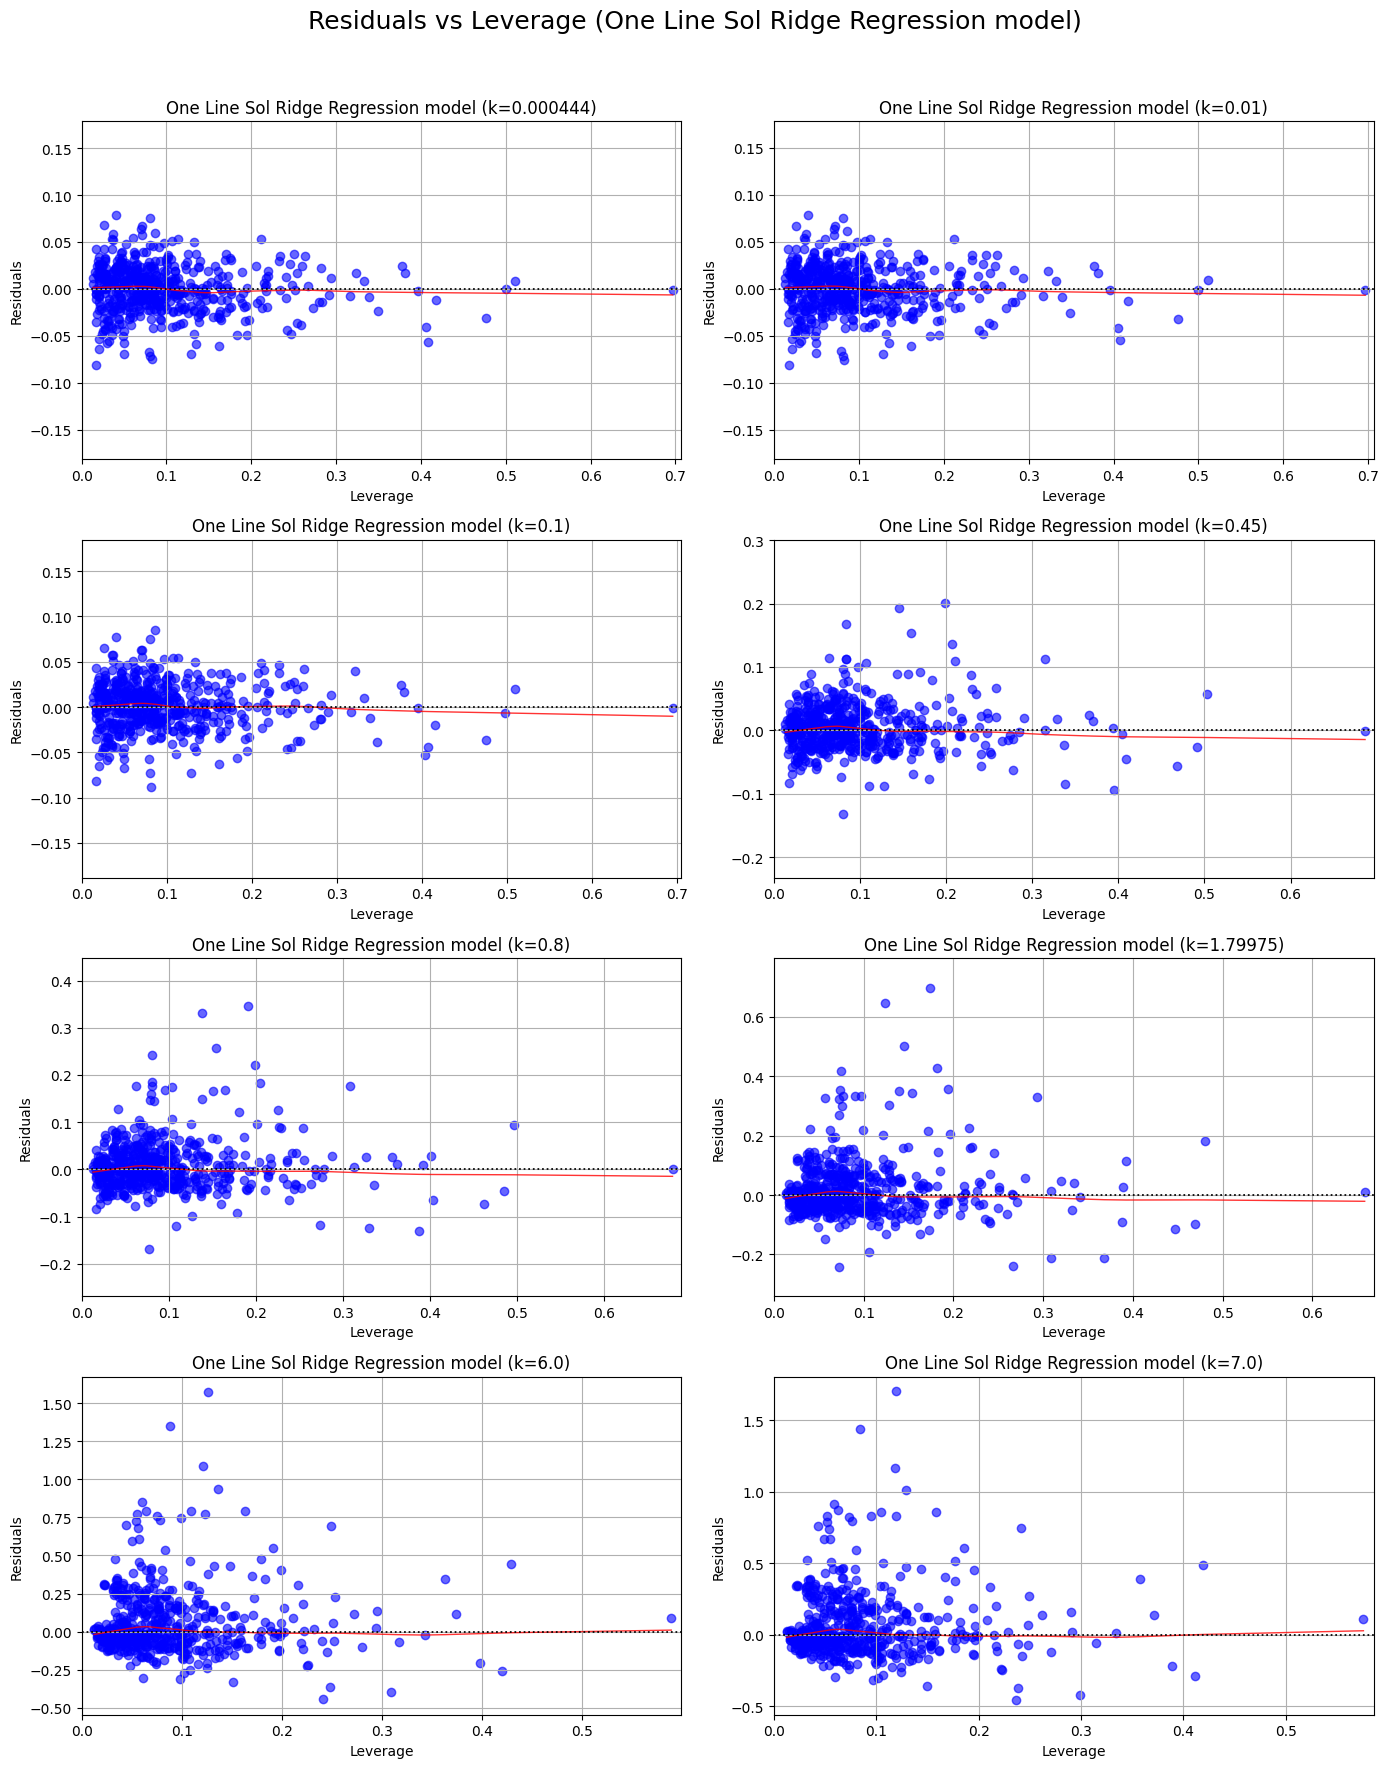

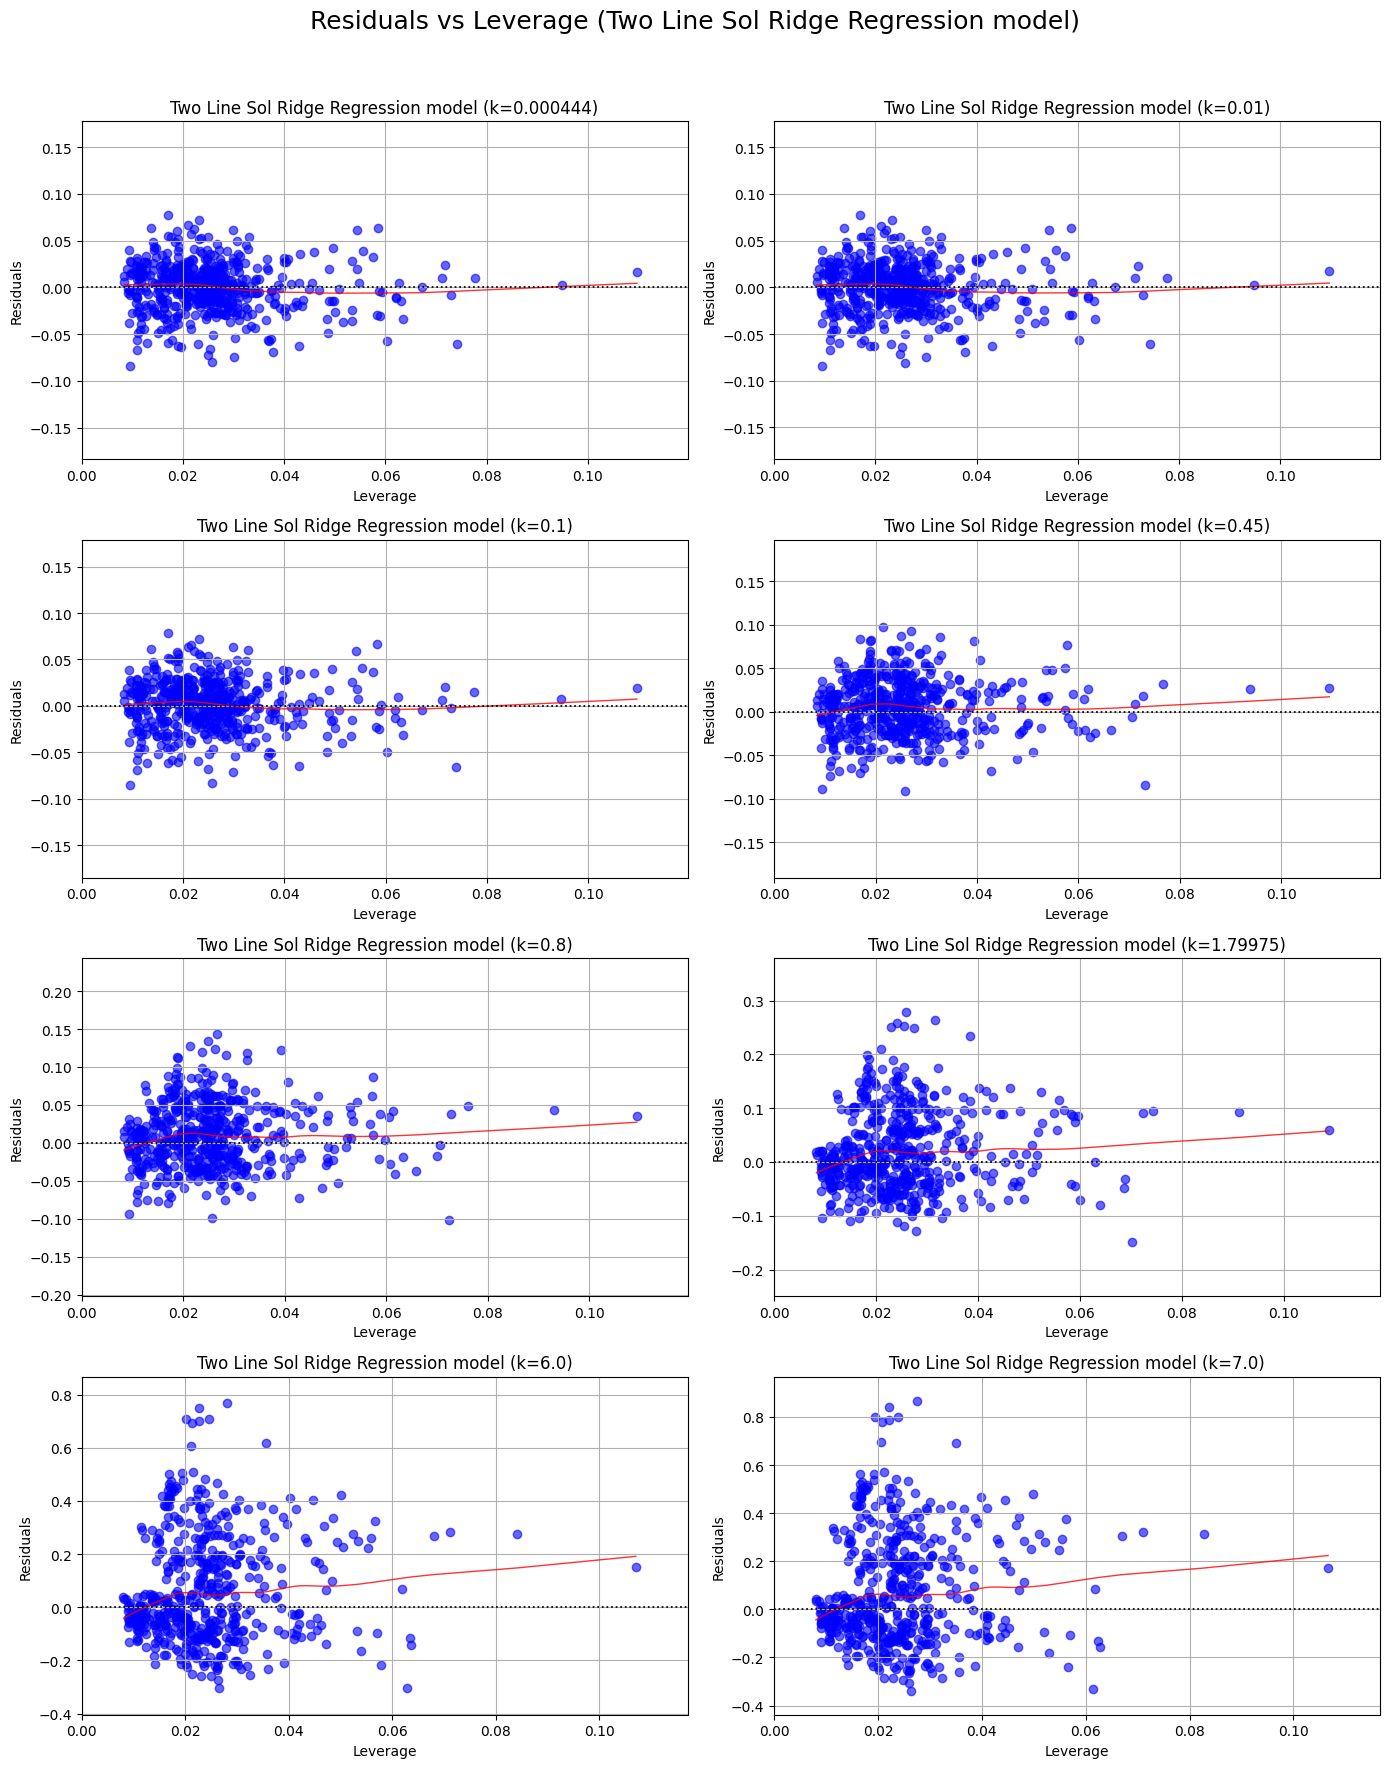

In [38]:
residuals_vs_leverage_plot(
    X_regressor=X_single_sol_bc,
    y_dependent=y_single_sol_bc,
    k_list=modified_optimum_k_concidered_all,
    model_name="One Line Sol Ridge Regression model"
)

residuals_vs_leverage_plot(
    X_regressor=X_two_sol_bc,
    y_dependent=y_two_sol_bc,
    k_list=modified_optimum_k_concidered_all,
    model_name="Two Line Sol Ridge Regression model"
)


#### Models validations:

Single and two line solutions. Cross validations single line solutions and learning curve

In [39]:
# Concatenate predictors and target into one DataFrame
df_one_line_sol = pd.concat([X_single_sol_bc, y_single_sol_bc], axis=1)


In [40]:
def ridge_regression_cv(Xregressor, y_dependent, k, k_val):
    """
    Perform ridge regression.
    Xregressor: Feature matrix (n_samples x n_features)
    y: Target vector (n_samples,)
    k_val: Regularization parameter (lambda)
    Returns: Coefficient vector beta
    """
    n_features = Xregressor.shape[1]
    I = np.eye(n_features)
    # Ridge estimator: (X'X + λI)^(-1) X'y
    beta__ = np.linalg.inv(Xregressor.T @ Xregressor + k_val * I) @ (Xregressor.T @ y_dependent)
    return beta__

def k_fold_cross_validation(df_one_line_sol: pd.DataFrame, k_val: float, k_fold: int = 5):
    # Separate predictors and target
    Xregressor = df_one_line_sol.drop(columns=["PR_BC"]).values
    y_dependent = df_one_line_sol["PR_BC"].values

    n_samples = Xregressor.shape[0]
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    fold_size = n_samples // k_fold
    mse_scores = []

    for i in range(k_fold):
        # Split indices into train/test
        test_idx = indices[i * fold_size:(i + 1) * fold_size]
        train_idx = np.setdiff1d(indices, test_idx)

        X_train__, y_train__ = Xregressor[train_idx], y_dependent[train_idx]
        X_test__, y_test__ = Xregressor[test_idx], y_dependent[test_idx]

        # Fit ridge regression
        betaR__ = ridge_regression_cv(X_train__, y_train__, k_fold, k_val)

        # Predict
        y_pred = X_test__ @ betaR__

        # Compute mean squared error
        mse = np.mean((y_test__ - y_pred) ** 2)
        mse_scores.append(mse)

    return np.mean(mse_scores)

In [41]:
k_list_ = optimum_k_concidered_all
avg_mse_list = []
for ik in k_list_:
    avg_mse = k_fold_cross_validation(df_one_line_sol = df_one_line_sol,                                  
                                  k_val = ik, 
                                  k_fold=5
                                  )
    avg_mse_list.append(avg_mse)

print(f"k val {ik} Average MSE across folds: {avg_mse:.4f}")  
  
# After filling avg_mse_list
min_mse = min(avg_mse_list)   
df_mse = pd.DataFrame({'k val':k_list_,'mse':np.round(avg_mse_list,3)})                             # find minimum MSE
min_index = avg_mse_list.index(min_mse)              # index of minimum MSE
best_k = k_list_[min_index]                          # corresponding k value

print(df_mse)
print(f"Minimum MSE: {min_mse:.4f} at k = {best_k}")

k val 7.0 Average MSE across folds: 0.1013
       k val    mse
0   0.000444  0.001
1   0.010000  0.001
2   0.100000  0.001
3   0.200000  0.001
4   0.430000  0.003
5   0.440000  0.002
6   0.450000  0.003
7   0.500000  0.003
8   0.600000  0.004
9   0.700000  0.005
10  0.800000  0.006
11  1.589000  0.015
12  1.848000  0.020
13  1.879000  0.024
14  1.883000  0.022
15  5.000000  0.068
16  6.000000  0.088
17  7.000000  0.101
Minimum MSE: 0.0008 at k = 0.000444


In [42]:
# Concatenate predictors and target into one DataFrame
df_two_line_sol = pd.concat([X_two_sol_bc, y_two_sol_bc], axis=1)
y_two_sol_bc.columns

Index(['PR_BC'], dtype='object')

In [43]:
k_list_ = optimum_k_concidered_all
avg_mse_list = []
for ik in k_list_:
    avg_mse = k_fold_cross_validation(df_one_line_sol = df_two_line_sol,                                  
                                  k_val = ik, 
                                  k_fold=5
                                  )
    avg_mse_list.append(avg_mse)

print(f"k val {ik} Average MSE across folds: {avg_mse:.4f}")  
  
# After filling avg_mse_list
min_mse = min(avg_mse_list)   
df_mse = pd.DataFrame({'k val':k_list_,'mse':np.round(avg_mse_list,3)})                             # find minimum MSE
min_index = avg_mse_list.index(min_mse)              # index of minimum MSE
best_k = k_list_[min_index]                          # corresponding k value

print(df_mse)
print(f"Minimum MSE: {min_mse:.4f} at k = {best_k}")

k val 7.0 Average MSE across folds: 0.0800
       k val    mse
0   0.000444  0.001
1   0.010000  0.001
2   0.100000  0.001
3   0.200000  0.001
4   0.430000  0.001
5   0.440000  0.001
6   0.450000  0.001
7   0.500000  0.001
8   0.600000  0.002
9   0.700000  0.002
10  0.800000  0.003
11  1.589000  0.007
12  1.848000  0.009
13  1.879000  0.010
14  1.883000  0.010
15  5.000000  0.048
16  6.000000  0.066
17  7.000000  0.080
Minimum MSE: 0.0007 at k = 0.01


In [44]:
from sklearn.linear_model import RidgeCV

# Define penalty parameters
ridge_penalty_param = ridge_penalty_param

# RidgeCV with 5-fold cross-validation
ridge_cv_model = RidgeCV(alphas=ridge_penalty_param, cv=5, scoring='neg_mean_squared_error')

# Fit the model
ridge_cv_model.fit(X_single_sol_bc, y_single_sol_bc)

# Best alpha and best score
print(f"Best alpha: {ridge_cv_model.alpha_}")
print(f"Best score (neg MSE): {ridge_cv_model.best_score_:.4f}")


Best alpha: 1.0
Best score (neg MSE): -0.0013


In [45]:
_,df_accureacy  = ridge_residuals_wrapper(X_regressor = X_single_sol, 
                                   y_var = y_single_sol, 
                                   k_list = optimum_k_concidered_all
                                   )
tableDispFormatt('Model:One Line Sol Accureacy calculations')
max_row = df_accureacy.loc[df_accureacy['R2_score'].idxmax()]
print(max_row)
max_row_mse = df_accureacy.loc[df_accureacy['MSE'].idxmin()]
print(max_row_mse)
print(df_accureacy)

_,df_accureacy  = ridge_residuals_wrapper(X_regressor = X_single_sol_bc, 
                                   y_var = y_single_sol_bc, 
                                   k_list = optimum_k_concidered_all
                                   )
tableDispFormatt('Model:One Line Sol with box cox Accureacy calculations')
max_row = df_accureacy.loc[df_accureacy['R2_score'].idxmax()]
print(max_row)
max_row_mse = df_accureacy.loc[df_accureacy['MSE'].idxmin()]
print(max_row_mse)
print(df_accureacy)

_,df_accureacy  = ridge_residuals_wrapper(X_regressor = X_two_sol, 
                                   y_var = y_two_sol, 
                                   k_list = optimum_k_concidered_all
                                   )
tableDispFormatt('Model:Two Line Sol Accureacy calculations')
max_row = df_accureacy.loc[df_accureacy['R2_score'].idxmax()]
print(max_row)
max_row_mse = df_accureacy.loc[df_accureacy['MSE'].idxmin()]
print(max_row_mse)
print(df_accureacy)

_,df_accureacy  = ridge_residuals_wrapper(X_regressor = X_two_sol_bc, 
                                   y_var = y_two_sol_bc, 
                                   k_list = optimum_k_concidered_all
                                   )
tableDispFormatt('Model:Two Line Sol with Box Cox Accureacy calculations')
max_row = df_accureacy.loc[df_accureacy['R2_score'].idxmax()]
print(max_row)
max_row_mse = df_accureacy.loc[df_accureacy['MSE'].idxmin()]
print(max_row_mse)
print(df_accureacy)

=============================== Model:One Line Sol Accureacy calculations ==================
k           4.440000e-04
R2_score    7.390102e-01
MSE         9.114091e+11
Name: 0, dtype: float64
k           4.440000e-04
R2_score    7.390102e-01
MSE         9.114091e+11
Name: 0, dtype: float64
           k  R2_score           MSE
0   0.000444  0.739010  9.114091e+11
1   0.010000  0.739010  9.114092e+11
2   0.100000  0.739007  9.114197e+11
3   0.200000  0.738998  9.114505e+11
4   0.430000  0.738958  9.115904e+11
5   0.440000  0.738956  9.115985e+11
6   0.450000  0.738954  9.116068e+11
7   0.500000  0.738941  9.116504e+11
8   0.600000  0.738913  9.117488e+11
9   0.700000  0.738881  9.118614e+11
10  0.800000  0.738845  9.119873e+11
11  1.589000  0.738452  9.133598e+11
12  1.848000  0.738289  9.139272e+11
13  1.879000  0.738269  9.139982e+11
14  1.883000  0.738266  9.140075e+11
15  5.000000  0.735632  9.232044e+11
16  6.000000  0.734652  9.266274e+11
17  7.000000  0.733642  9.301568e+11
======

#### OLS Models:

0.7241055939179311


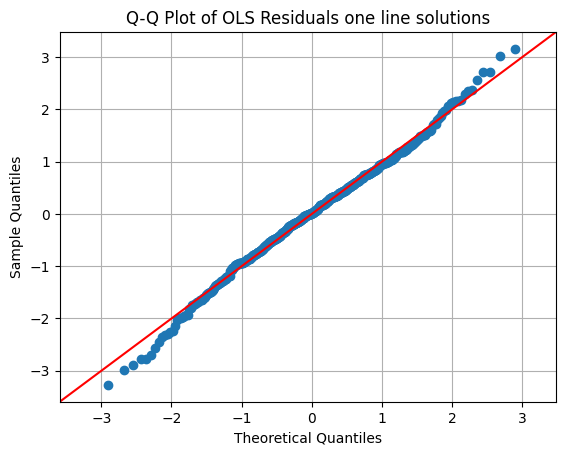

0.6946127674905891


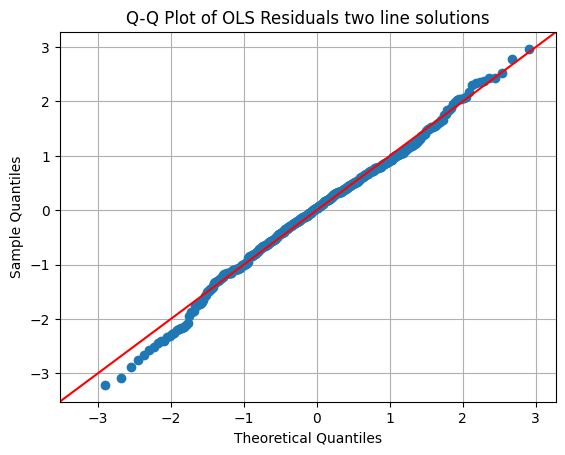

In [46]:
# OLS regression
models_one_line = sm.OLS(y_single_sol_bc, X_single_sol_bc)          # Describe model
res_single_line = models_one_line.fit() # Fit model
print(res_single_line.rsquared)
#print(res_single_line.summary())           # Summarize model
# Q-Q plot of residuals
sm.qqplot(res_single_line.resid, line='45', fit=True)
plt.title("Q-Q Plot of OLS Residuals one line solutions")
plt.grid(True)
plt.show()

# OLS regression
models_two_line = sm.OLS(y_two_sol_bc, X_two_sol_bc)          # Describe model
res_single_line = models_two_line.fit() # Fit model
print(res_single_line.rsquared)
#print(res_single_line.summary())           # Summarize model
# Q-Q plot of residuals
sm.qqplot(res_single_line.resid, line='45', fit=True)
plt.title("Q-Q Plot of OLS Residuals two line solutions")
plt.grid(True)
plt.show()


#### Accureacy Calculations 

TODO:

Next, we should work with OLS models and compare their performance against Ridge regression. We must also investigate these models with respect to homoscedasticity and heteroscedasticity. This analysis will help us conclude that if heteroscedasticity is present in the dataset, the performance of OLS tends to deteriorate, whereas Ridge regression may provide more reliable results.

